<a href="https://colab.research.google.com/github/Knchna/Credit_Card_Default_Prediction/blob/main/Credit_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Default Prediction
Includes data preprocessing, exploratory data analysis (EDA), feature analysis, classification model development, hyperparameter tuning, ensemble methods, and model evaluation.

Dataset: Default of Credit Card Clients (UCI Repository)

# Clone the Git

In [2]:
# Clone the GitHub repository into the Google Colab environment

!git clone https://github.com/Knchna/Credit_Default_Preprocessing.git

Cloning into 'Credit_Default_Preprocessing'...
remote: Enumerating objects: 183, done.
remote: Counting objects: 100% (89/89), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 183 (delta 52), reused 0 (delta 0), pack-reused 94 (from 1)
Receiving objects: 100% (183/183), 4.26 MiB | 6.96 MiB/s, done.
Resolving deltas: 100% (107/107), done.


# Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV,
                                     RandomizedSearchCV, KFold)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.utils.class_weight import compute_class_weight
from keras.utils import plot_model

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix)

# Read the Data

In [4]:
# filepath to the .excel file
# Load the dataset from the cloned GitHub repository

filepath = '/content/Credit_Default_Preprocessing/default of credit card clients.xls'
df_credit = pd.read_excel(filepath, header=1)
df_credit.head(20)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
5,6,50000,1,1,2,37,0,0,0,0,...,19394,19619,20024,2500,1815,657,1000,1000,800,0
6,7,500000,1,1,2,29,0,0,0,0,...,542653,483003,473944,55000,40000,38000,20239,13750,13770,0
7,8,100000,2,2,2,23,0,-1,-1,0,...,221,-159,567,380,601,0,581,1687,1542,0
8,9,140000,2,3,1,28,0,0,2,0,...,12211,11793,3719,3329,0,432,1000,1000,1000,0
9,10,20000,1,3,2,35,-2,-2,-2,-2,...,0,13007,13912,0,0,0,13007,1122,0,0


#EDA

In [5]:
# Identifying numerical and categorical data
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [6]:
# Identifying dataset size
df_credit.shape

(30000, 25)

In [7]:
df_credit.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


## Missing values

In [8]:
# Trying to findout if there is any missing value present
df_credit.isna().sum()

# no missing values found

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


## Duplicated columns

In [9]:
df_credit.duplicated().sum()

np.int64(0)

## Dropping Redundant Columns

In [10]:
# Dropping column ID because it has too many unique values
df_credit.drop(columns=['ID'], inplace=True)

# After dropping
df_credit.shape

(30000, 24)

## Replacing Impossible Values

In [11]:
# checking unique values of column = education
df_credit['EDUCATION'].unique()

array([2, 1, 3, 5, 4, 6, 0])

In [12]:
# replacing (0,5,6) as they are impossible values for education
df_credit['EDUCATION'] = df_credit['EDUCATION'].replace([0,5,6], 4)

# checking if the replace was successfull
df_credit['EDUCATION'].unique()

array([2, 1, 3, 4])

In [13]:
# checking unique values of column = marriage
df_credit['MARRIAGE'].unique()

array([1, 2, 3, 0])

In [14]:
# replacing (0) as they are impossible values for marriage
df_credit['MARRIAGE'] = df_credit['MARRIAGE'].replace([0], 3)

# checking if the replace was successfull
df_credit['MARRIAGE'].unique()

array([1, 2, 3])

## Separating Numerical and Categorical data

In [15]:
num_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

cat_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

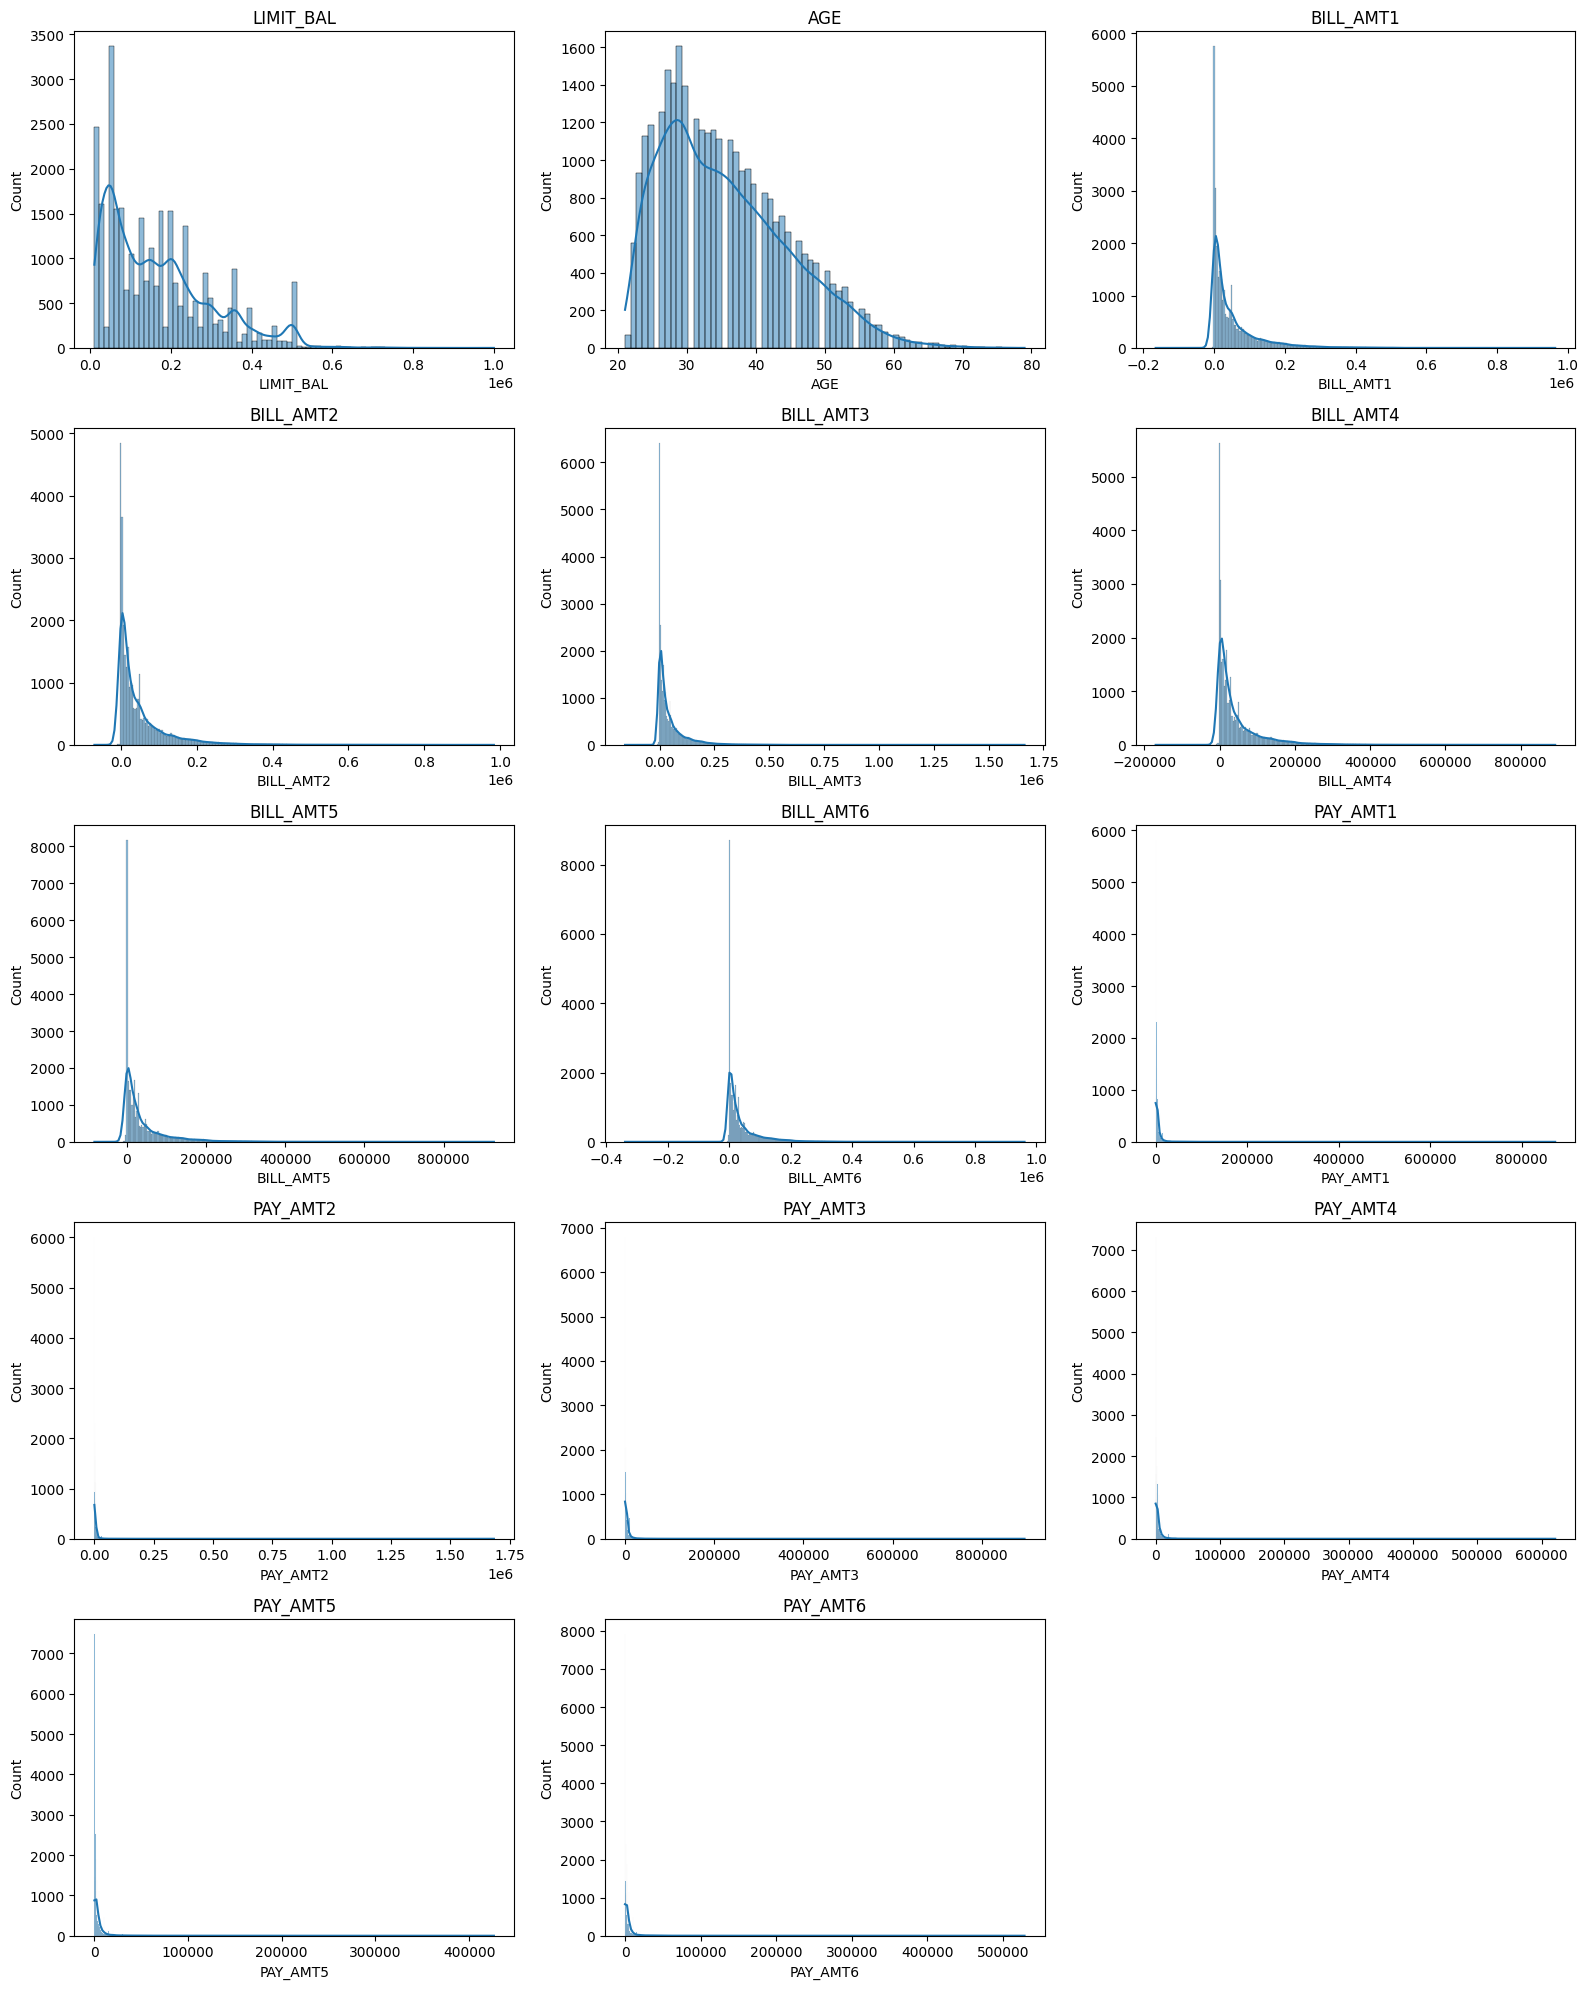

In [16]:
# Histogram of num_cols

plt.figure(figsize = (16, 20))
i = 1
for column in num_cols:
  plt.subplot(5, 3, i)
  sns.histplot(df_credit[column], kde=True)
  plt.title(column)
  i += 1
plt.tight_layout()
plt.show()

##Outlier Handling

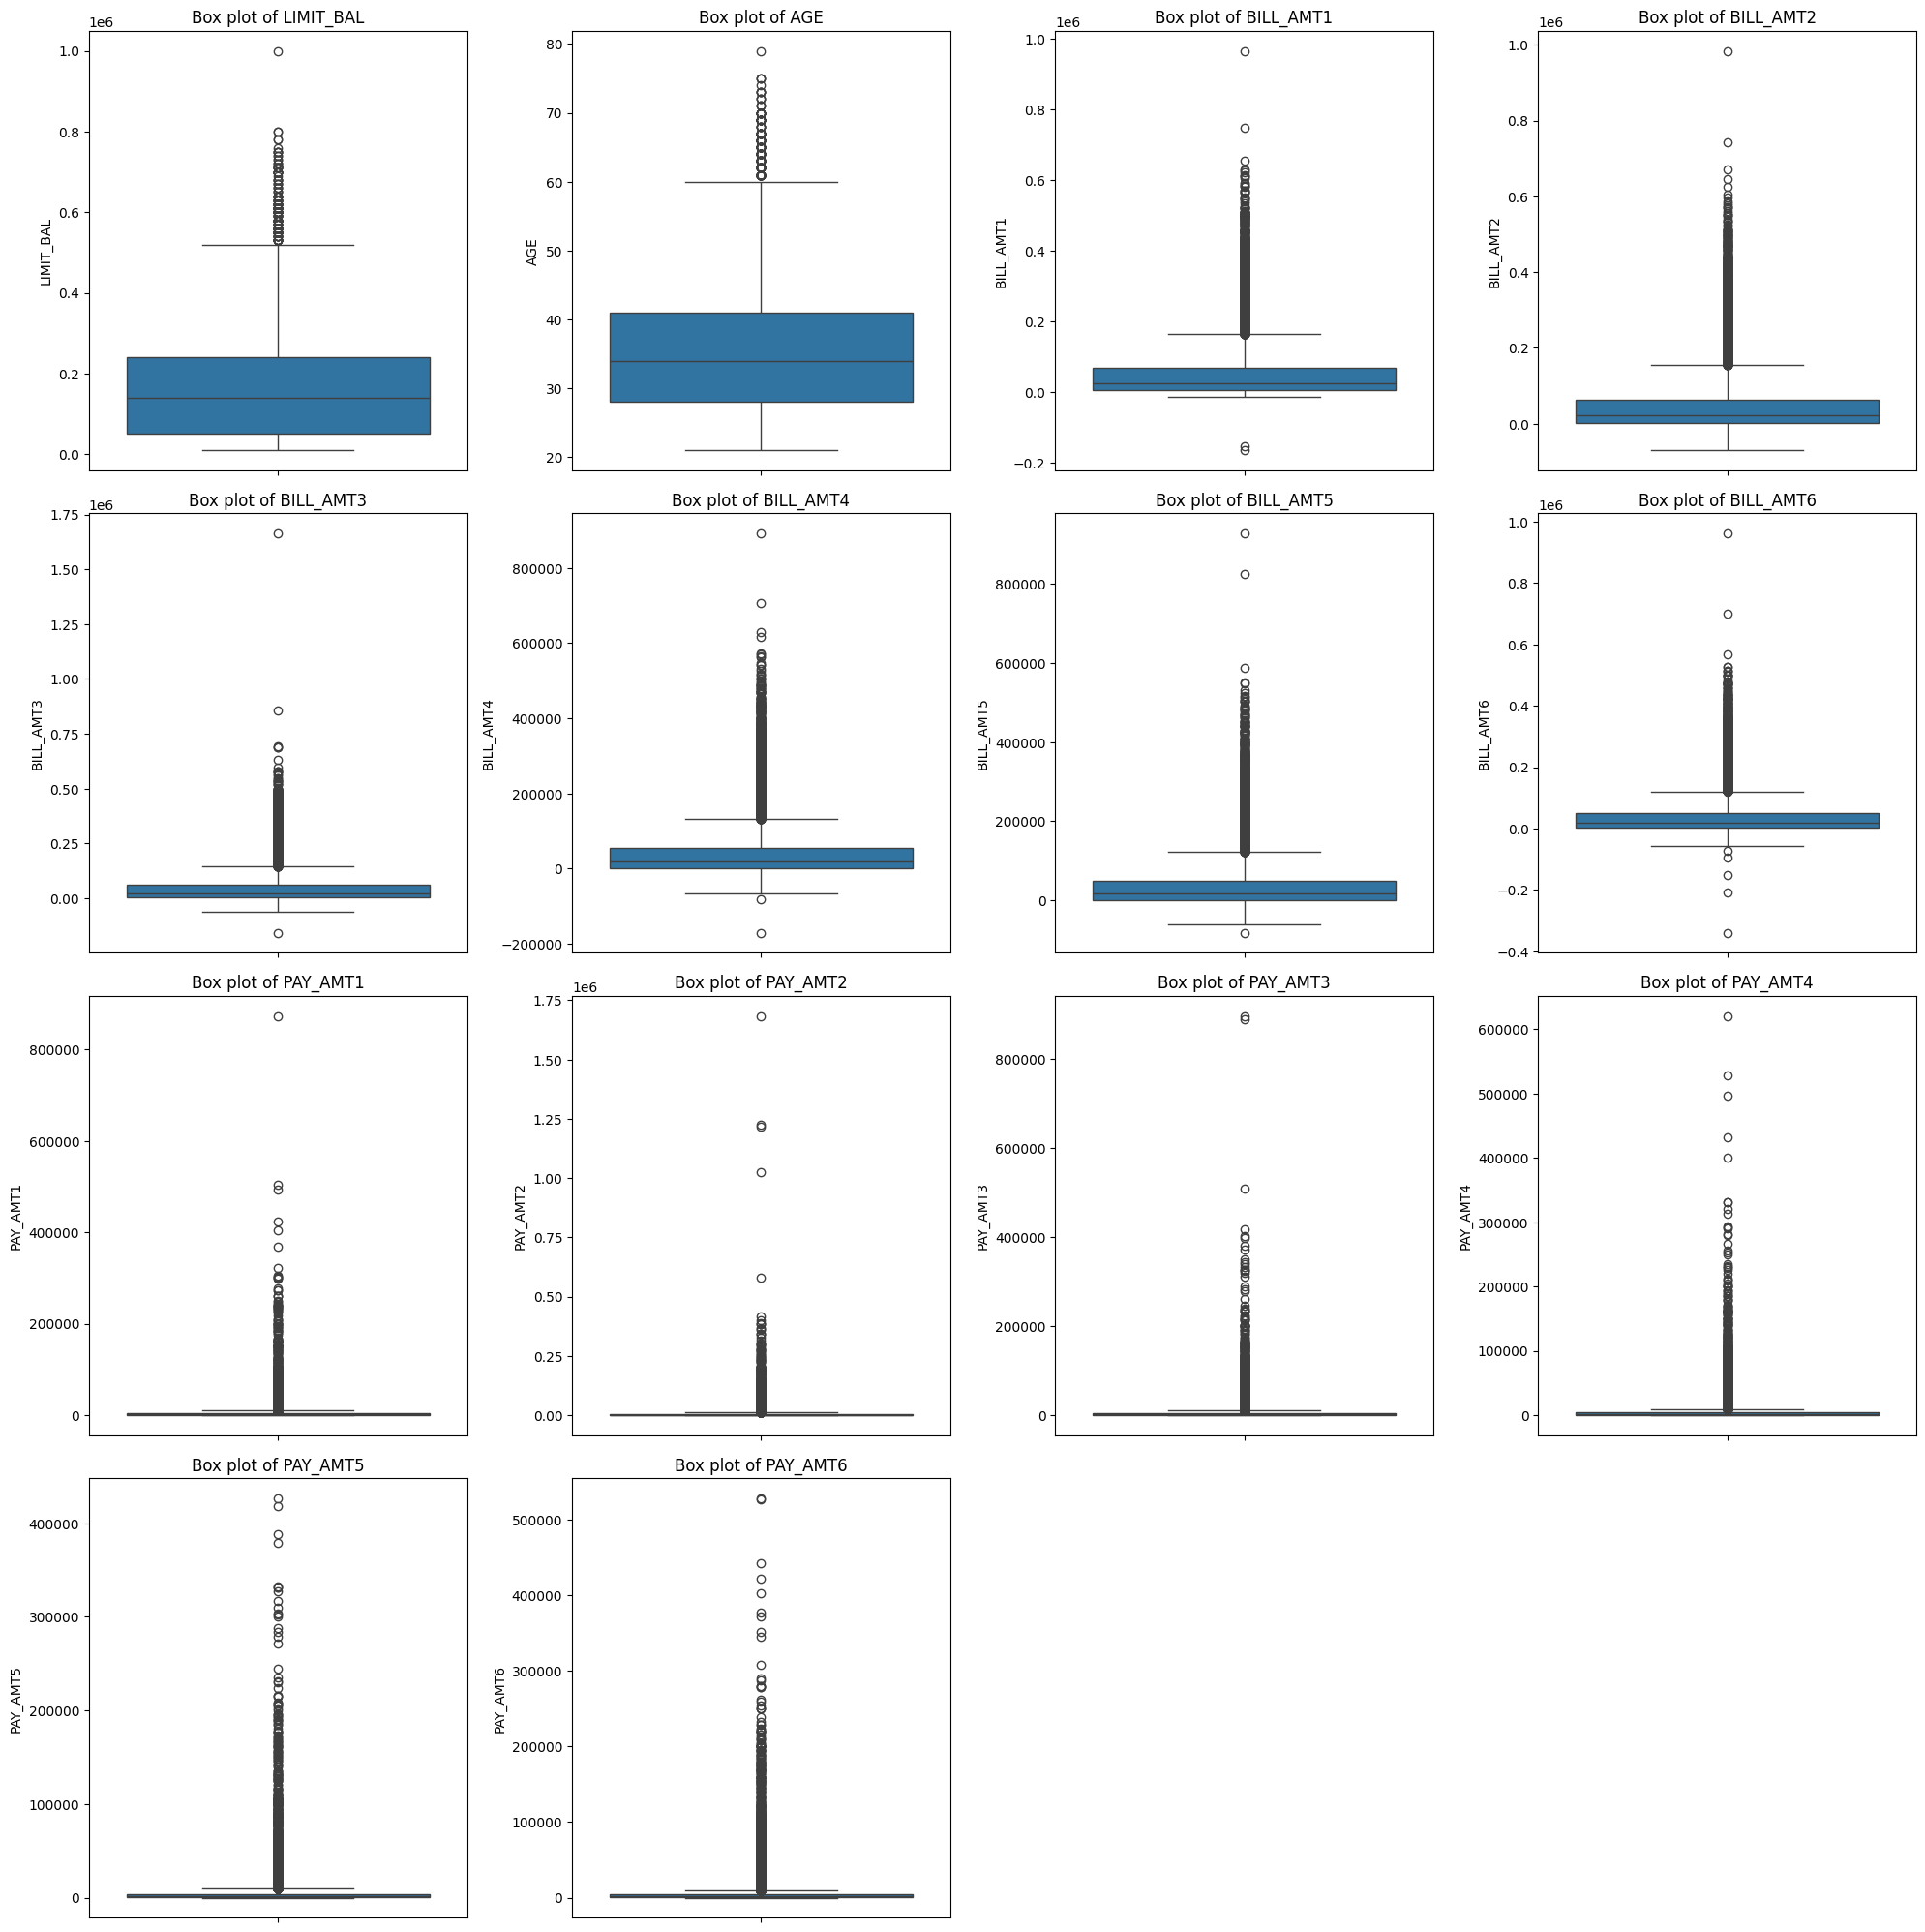

In [17]:
# Boxplot for handling outlier

plt.figure(figsize=(20, 25))

for i, column in enumerate(num_cols):
    plt.subplot(5, 4, i + 1)
    sns.boxplot(y = df_credit[column])
    plt.title(f'Box plot of {column}')

plt.tight_layout()
plt.show()

In [18]:
# Inferences from describe() and univariate analysis:
# Most numerical features are right skewed and contain extreme values.
# These extreme values represent genuine customer financial behavior rather than data entry errors.
# Therefore, outlier removal is not performed to preserve important information and avoid losing valid observations.

# Bivariate Analysis

## Plotting

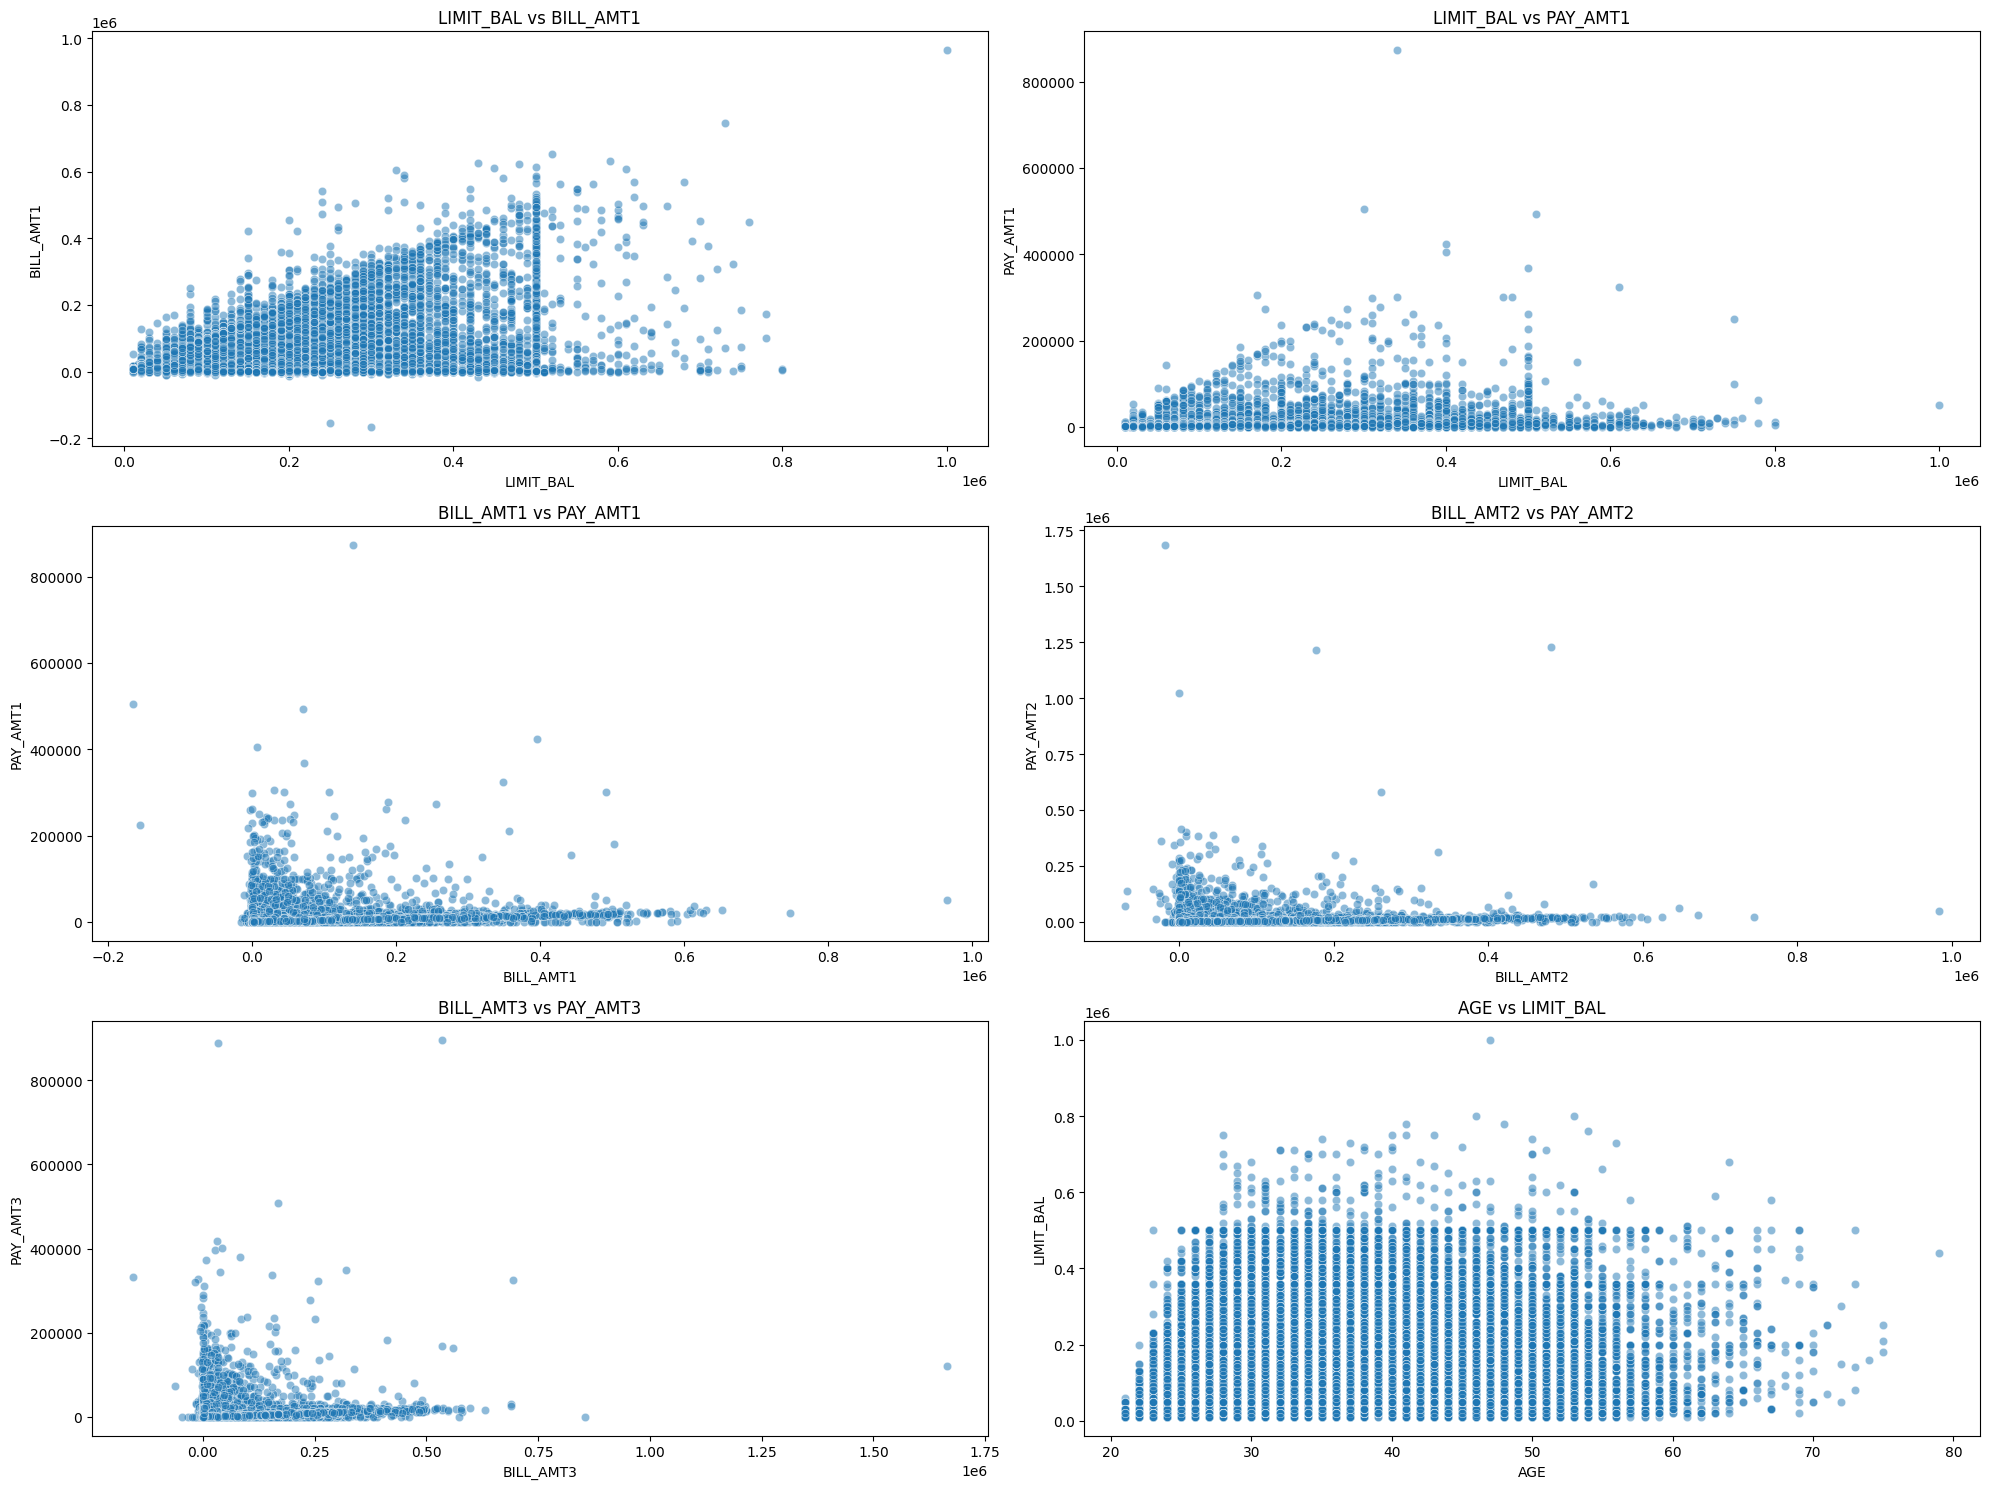

In [19]:
# Scatter plots for Bivariate Analysis
feature_pairs = [
    ('LIMIT_BAL', 'BILL_AMT1'),
    ('LIMIT_BAL', 'PAY_AMT1'),
    ('BILL_AMT1', 'PAY_AMT1'),
    ('BILL_AMT2', 'PAY_AMT2'),
    ('BILL_AMT3', 'PAY_AMT3'),
    ('AGE', 'LIMIT_BAL')
]

plt.figure(figsize=(20, 15))

for i, (x, y) in enumerate(feature_pairs):
    plt.subplot(3, 2, i + 1)
    sns.scatterplot(x = df_credit[x], y = df_credit[y], alpha = 0.5)
    plt.title(f'{x} vs {y}')
    plt.xlabel(x)
    plt.ylabel(y)

plt.tight_layout()
plt.show()

## Correlation

In [20]:
# Finding Pearson's correlation coefficient to measure linear relationship b/w continuous numerical columns

# Matrix 1: to find any mutli-collinearity b/w the 14 numerical features
corr_mat_num = df_credit[num_cols].corr()
corr_mat_num

,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
LIMIT_BAL,1.000000,0.144713,0.285430,0.278314,0.283236,0.293988,0.295562,0.290389,0.195236,0.178408,0.210167,0.203242,0.217202,0.219595
AGE,0.144713,1.000000,0.056239,0.054283,0.053710,0.051353,0.049345,0.047613,0.026147,0.021785,0.029247,0.021379,0.022850,0.019478
BILL_AMT1,0.285430,0.056239,1.000000,0.951484,0.892279,0.860272,0.829779,0.802650,0.140277,0.099355,0.156887,0.158303,0.167026,0.179341
BILL_AMT2,0.278314,0.054283,0.951484,1.000000,0.928326,0.892482,0.859778,0.831594,0.280365,0.100851,0.150718,0.147398,0.157957,0.174256
BILL_AMT3,0.283236,0.053710,0.892279,0.928326,1.000000,0.923969,0.883910,0.853320,0.244335,0.316936,0.130011,0.143405,0.179712,0.182326
BILL_AMT4,0.293988,0.051353,0.860272,0.892482,0.923969,1.000000,0.940134,0.900941,0.233012,0.207564,0.300023,0.130191,0.160433,0.177637
BILL_AMT5,0.295562,0.049345,0.829779,0.859778,0.883910,0.940134,1.000000,0.946197,0.217031,0.181246,0.252305,0.293118,0.141574,0.164184
BILL_AMT6,0.290389,0.047613,0.802650,0.831594,0.853320,0.900941,0.946197,1.000000,0.199965,0.172663,0.233770,0.250237,0.307729,0.115494
PAY_AMT1,0.195236,0.026147,0.140277,0.280365,0.244335,0.233012,0.217031,0.199965,1.000000,0.285576,0.252191,0.199558,0.148459,0.185735
PAY_AMT2,0.178408,0.021785,0.099355,0.100851,0.316936,0.207564,0.181246,0.172663,0.285576,1.000000,0.244770,0.180107,0.180908,0.157634


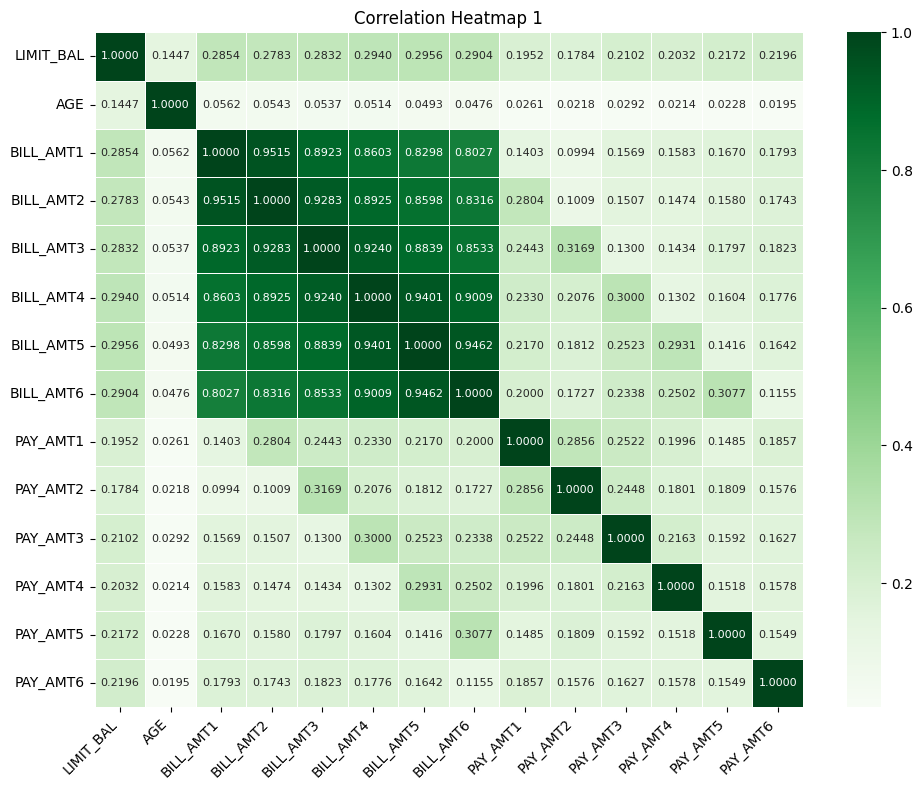

In [21]:
# Correlation Heatmap 1: of only numerical feature cols

plt.figure(figsize=(10,8))
sns.heatmap(
    corr_mat_num,
    annot=True,
    fmt=".4f",
    cmap="Greens",
    linewidths=0.5,
    annot_kws={"size":8}
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title('Correlation Heatmap 1')

plt.tight_layout()
plt.show()

In [22]:
# Inference:
    # The BILL_AMT variables exhibit high positive correlations, especially b/w adjacent months.
    # Since these features capture historical information rather than duplicate measurements, they were retained

In [23]:
# Matrix 2: to check collinearity b/w the 14 numerical features and target feature
corr_mat_target = df_credit[num_cols + ['default payment next month']].corr()
corr_mat_target['default payment next month']

,default payment next month
LIMIT_BAL,-0.153520
AGE,0.013890
BILL_AMT1,-0.019644
BILL_AMT2,-0.014193
BILL_AMT3,-0.014076
BILL_AMT4,-0.010156
BILL_AMT5,-0.006760
BILL_AMT6,-0.005372
PAY_AMT1,-0.072929
PAY_AMT2,-0.058579


# Train-Test Split

In [24]:
# Split into features and target
y = df_credit['default payment next month']                            # Target
X = df_credit.drop(columns=['default payment next month'], axis=1)     # Feature

# Split into test train data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=45, stratify=y)

# Mutual Information

In [25]:
discrete_mask = X.columns.isin(cat_cols)    # creating Boolean mask

# Mutual Information Classifier
mi = mutual_info_classif(X, y, discrete_features = discrete_mask, random_state = 42)
mi

array([0.01519361, 0.00079304, 0.00296187, 0.00046822, 0.00314013,
       0.07605263, 0.04905609, 0.0372781 , 0.0328878 , 0.0305436 ,
       0.02642224, 0.01116204, 0.00631931, 0.00642298, 0.00262078,
       0.0076454 , 0.00547025, 0.02330462, 0.01628362, 0.01694217,
       0.01581689, 0.01279914, 0.01052787])

In [26]:
# Converting mi array to Series with index as the column names of X
mi_scores = pd.Series(mi, index = X.columns, name = "Mutual Information")
mi_scores = mi_scores.sort_values(ascending = False)
mi_scores

,Mutual Information
PAY_0,0.076053
PAY_2,0.049056
PAY_3,0.037278
PAY_4,0.032888
PAY_5,0.030544
PAY_6,0.026422
PAY_AMT1,0.023305
PAY_AMT3,0.016942
PAY_AMT2,0.016284
PAY_AMT4,0.015817


In [27]:
# Inference:
  # demographic variables - AGE, EDUCATION, SEX and MARRIAGE showed relatively low mutual information, but they were retained as:
    # they represent meaningful customer characteristics

# If absolutely required, cols SEX and MARRIAGE can be dropped as they show almost 0 MI.

# Scaling

In [28]:
# Scale only numerical columns using the Standard Scaler

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Display information

print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("y_train shape :", y_train.shape)
print("y_test shape  :", y_test.shape)

# Display the first five rows of the scaled numerical features.
print("\n Scaled Training Data:")
X_train[num_cols].head(5)

# The scaler is fitted on the training data and then applied to the test data to prevent data leakage.
# Standardize numerical features to improve the performance of Logistic Regression, SVM, and KNN.
# Scale numerical features such as LIMIT_BAL, AGE, BILL_AMT1–BILL_AMT6, and PAY_AMT1–PAY_AMT6.
# StandardScaler handles varying feature ranges and outliers better than MinMaxScaler.

X_train shape : (24000, 23)
X_test shape  : (6000, 23)
y_train shape : (24000,)
y_test shape  : (6000,)

 Scaled Training Data:


,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
18131,0.564567,0.161886,-0.639251,-0.583478,1.573517,-0.521762,-0.475118,-0.586345,0.130811,7.787364,0.266780,0.450873,-0.060157,-0.095742
5197,-0.901149,0.703643,-0.041506,-0.019100,0.015256,0.080000,0.133173,0.169947,-0.231367,-0.193236,-0.194276,-0.193870,-0.193485,-0.187858
26852,1.490281,0.378589,-0.677657,-0.672988,-0.664293,-0.652107,-0.642274,-0.629895,-0.285202,-0.236987,-0.232237,-0.236835,-0.236732,-0.223771
23592,-0.669720,0.378589,-0.404198,-0.375025,-0.346277,-0.323156,-0.285916,-0.257502,-0.256590,-0.235996,-0.307149,-0.266890,-0.260826,1.410033
27474,1.490281,1.462103,1.631212,1.473410,1.306837,1.120672,1.178628,1.207264,0.006001,-0.022978,-0.030076,-0.060067,-0.058194,-0.029142


# Feature Encoding

In [29]:
# Check for categorical (object) columns

cat_cols = df_credit.select_dtypes(include=['object']).columns
print("Categorical Columns:", cat_cols)
if len(cat_cols) == 0:
    print("No encoding required. All categorical features are already numerically encoded.")

Categorical Columns: Index([], dtype='object')
No encoding required. All categorical features are already numerically encoded.


In [30]:
# Categorical Feature Encoding
# Categorical features (SEX, EDUCATION, MARRIAGE, and PAY_0–PAY_6) are already numerically encoded.

# Feature Engineering Decisions

In [31]:
# Dropped the ID Column

# Decision:- Drop the ID column
# Reason:- It is a unique identifier and not useful for prediction.

In [32]:
# Identified the target variable

# Target Column: 'default payment next month'
# Reason: This column indicates whether a customer defaulted on their payment in the following month.
# 0 = No Default
# 1 = Default

In [33]:
# Categorical features

# SEX, EDUCATION, MARRIAGE, PAY_0, PAY_2, PAY_3, PAY_4, PAY_5, PAY_6
# Reason: These variables represent categories rather than continuous numerical values.
# Although stored as integers, their values indicate labels or ordered categories.

In [34]:
# Numerical features

# LIMIT_BAL, AGE, BILL_AMT1–BILL_AMT6, PAY_AMT1–PAY_AMT6
# Reason: These columns contain continuous numerical values.
# Arithmetic operations such as mean, variance, and standard deviation are meaningful for these features.

In [35]:
# Applied Feature Scaling

# Method: StandardScaler to numerical features after train-test split.
# Standardizes data (mean = 0, std = 1) and helps prevent data leakage.
# MinMaxScaler was not used because it is sensitive to outliers.

In [36]:
# Feature Selection

# Retained all features except 'ID' as they contribute to credit default prediction.
# LIMIT_BAL: Credit limit
# AGE: Customer age
# PAY_0–PAY_6: Repayment history
# BILL_AMT1–BILL_AMT6: Monthly bill amounts
# PAY_AMT1–PAY_AMT6: Monthly repayment amounts

# Verify final dataset

In [37]:
# Check the shape of the datasets
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)
print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

# Check for missing values
print("\nMissing values in X_train:")
print(X_train.isnull().sum())

print("\nMissing values in X_test:")
print(X_test.isnull().sum())

# Verify data types
print("\nData Types:")
print(X_train.dtypes)

# Display first five rows of the processed training data
print("\nProcessed Training Data:")
print(X_train.head(5))

Training Features Shape : (24000, 23)
Testing Features Shape  : (6000, 23)
Training Target Shape   : (24000,)
Testing Target Shape    : (6000,)

Missing values in X_train:
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
dtype: int64

Missing values in X_test:
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
dtype: int64

Data Types:
LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE 

# Save the final preprocessed dataset


In [38]:
# Save training dataset
# train_data = X_train.copy()
# train_data['default payment next month'] = y_train
# train_data.to_csv('credit_default_train.csv', index=False)

# # Save testing dataset
# test_data = X_test.copy()
# test_data['default payment next month'] = y_test
# test_data.to_csv('credit_default_test.csv', index=False)

# print("Training and testing datasets saved successfully!")

In [39]:
# Downloading the train and test file
# from google.colab import files
# files.download('credit_default_train.csv')
# files.download('credit_default_test.csv')

### Summary of Preprocessing Steps

1. Loaded the dataset into a Excel file.
2. Inspected the dataset using head(), info(), describe(), missing values and duplicates.
3. Removed the 'ID' column as it is a unique identifier and does not contribute to prediction.
4. Identified 'default payment next month' as the target variable and separated the feature and target columns.
5. Classified the features into categorical ('SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0'–'PAY_6') and numerical ('LIMIT_BAL', 'AGE', 'BILL_AMT1'–'BILL_AMT6', 'PAY_AMT1'–'PAY_AMT6') columns.
6. Split the dataset into 80% training and 20% testing sets using 'train_test_split()'.
7. Conducted correlation analysis.
8. Calculated Mutual Information scores for feature importance.
9. Applied StandardScaler to scale only the numerical features, while keeping the categorical features unchanged.
10. Verified the processed dataset by checking its shape, data types, missing values, and sample records.
11. Saved the final preprocessed training and testing datasets for model development.

# Model Building

## Logistic Regression

### Baseline Logistic Regression

In [40]:
# creating object
log_reg = LogisticRegression()

# train the model
log_reg.fit(X_train, y_train)

# make predictions on X_test
y_pred_log_reg = log_reg.predict(X_test)

In [41]:
# evaluate the model by comparing with y_test
print("Evaluating Baseline Logistic Regression Model:")

print("\nAccuracy :", accuracy_score(y_test, y_pred_log_reg))
print("Precision :", precision_score(y_test, y_pred_log_reg))
print("Recall :", recall_score(y_test, y_pred_log_reg))
print("F1 Score :", f1_score(y_test, y_pred_log_reg))

clsf_log_reg = classification_report(y_test,y_pred_log_reg)
print("\nClassification Report :")
print(clsf_log_reg)

conf_log_reg = confusion_matrix(y_test, y_pred_log_reg)
print("\nConfusion Matrix :")
print(conf_log_reg)

Evaluating Baseline Logistic Regression Model:

Accuracy : 0.812
Precision : 0.7297921478060047
Recall : 0.23813112283345894
F1 Score : 0.35909090909090907

Classification Report :
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.73      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.77      0.61      0.62      6000
weighted avg       0.80      0.81      0.77      6000


Confusion Matrix :
[[4556  117]
 [1011  316]]


### Cross-Validation

#### K-Fold Cross Validation

In [42]:
# StratifiedKFold ensures that every fold maintains approximately the same class distribution.
cv_kfold = StratifiedKFold(
    n_splits=5,      # Split the training data into 5 folds   =>  k=5
    shuffle=True,    # Shuffle the data before splitting
    random_state=45  # Ensures reproducibility
)

# Create the baseline Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)

# Perform 5-Fold Cross Validation on the TRAINING DATA ONLY
cv_kfold_scores = cross_val_score(
    estimator=log_reg,
    X=X_train,
    y=y_train,
    cv=cv_kfold,
    scoring='recall'    # scoring='recall' because correctly detecting actual default customers is more important than simple accuracy
)

**Recall** was chosen because:

* The main objective is to identify as many defaulting customers as possible.
* In credit default prediction, missing a true defaulter (False Negative) is generally more costly than incorrectly classifying a non-defaulter as a defaulter (False Positive).
* Although F1-score provides a balance between Precision and Recall, Recall was prioritized since minimizing missed defaulters was the primary objective of this project.

In [43]:
print("5 k-Fold Cross Validation Recall Scores:")
print(cv_kfold_scores)

print("\nMean Recall:", cv_kfold_scores.mean())
print("Standard Deviation:", cv_kfold_scores.std())

5 k-Fold Cross Validation Recall Scores:
[0.22431668 0.24764595 0.22881356 0.22504708 0.23822976]

Mean Recall: 0.23281060577822504
Standard Deviation: 0.008920202706131666


#### Hyperparameter Tuning using GridSearchCV

In [44]:
# Define the hyperparameters to be tested
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10],                  # C              -> Regularization strength
    'solver': ['liblinear'],                  # solver         -> Optimization algorithm
    'penalty': ['l1', 'l2'],                  # penalty        -> Regularization type
    'class_weight': [None, 'balanced']        # class_weight   -> Gives higher importance to the minority class
}

# Build the Grid Search model
lr_grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_grid=lr_param_grid,
    cv=5,
    scoring='recall',           # Optimizing for Recall
    n_jobs=-1
)

# Train the Grid Search model on the training data
lr_grid.fit(X_train, y_train)

# Display the best hyperparameters found
print("Best Parameters:")
print(lr_grid.best_params_)

print("\nBest Cross Validation Recall:")
print(lr_grid.best_score_)

Best Parameters:
{'C': 1, 'class_weight': 'balanced', 'penalty': 'l1', 'solver': 'liblinear'}

Best Cross Validation Recall:
0.6490870461189475


In [45]:
# Retrieve the best model identified by GridSearchCV
lr_best_model_grid = lr_grid.best_estimator_

# Predict on the unseen test data
y_pred_lr_grid = lr_best_model_grid.predict(X_test)

In [46]:
# Evaluating GridSearchCV optimized model

print("Evaluating GridSearchCV optimized model:")

print("\nAccuracy :", accuracy_score(y_test, y_pred_lr_grid))
print("Precision :", precision_score(y_test, y_pred_lr_grid))
print("Recall :", recall_score(y_test, y_pred_lr_grid))
print("F1 Score :", f1_score(y_test, y_pred_lr_grid))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr_grid))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr_grid))

Evaluating GridSearchCV optimized model:

Accuracy : 0.6915
Precision : 0.3818755635707845
Recall : 0.6382818387339865
F1 Score : 0.47785613540197464

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.71      0.78      4673
           1       0.38      0.64      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.76      0.69      0.71      6000


Confusion Matrix:

[[3302 1371]
 [ 480  847]]


#### Randomized Search CV

In [47]:
# Define the Hyperparameter Search Space
lr_rand_param_dist = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'class_weight': [None, 'balanced']
}

# Create the Randomized Search Model
lr_random_search = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=45),
    param_distributions=lr_rand_param_dist,
    n_iter=10,                        # n_iter = Number of random parameter combinations to test. choosing 10 out of 20
    scoring='recall',
    cv=5,
    random_state=45,
    n_jobs=-1
)

# Train the Randomized Search Model
lr_random_search.fit(X_train, y_train)

# Display the Best Hyperparameters
print("Best Parameters:")
print(lr_random_search.best_params_)

print("\nBest Cross Validation Recall:")
print(lr_random_search.best_score_)

Best Parameters:
{'solver': 'liblinear', 'penalty': 'l1', 'class_weight': 'balanced', 'C': 1}

Best Cross Validation Recall:
0.6490870461189475


In [48]:
# Retrieve the best model found by RandomizedSearchCV
best_model_lr_random = lr_random_search.best_estimator_

# Predict on the unseen test data
y_pred_lr_random = best_model_lr_random.predict(X_test)

In [49]:
# Evaluate the RandomizedSearchCV Model

print("Evaluating RandomizedSearchCV Optimized Model\n")

print("Accuracy :", accuracy_score(y_test, y_pred_lr_random))
print("Precision :", precision_score(y_test, y_pred_lr_random))
print("Recall :", recall_score(y_test, y_pred_lr_random))
print("F1 Score :", f1_score(y_test, y_pred_lr_random))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr_random))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr_random))

Evaluating RandomizedSearchCV Optimized Model

Accuracy : 0.6915
Precision : 0.3818755635707845
Recall : 0.6382818387339865
F1 Score : 0.47785613540197464

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.71      0.78      4673
           1       0.38      0.64      0.48      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.67      0.63      6000
weighted avg       0.76      0.69      0.71      6000


Confusion Matrix:

[[3302 1371]
 [ 480  847]]


### Conclusion

Since the primary objective of credit default prediction is to minimize false negatives and detect as many potential defaulters as possible,   
The **GridSearchCV-optimized for Recall** was selected as the final Logistic Regression Model  
So the best paramters found after GridSearchCV will be applied hereafter

### Ensemble Modelling - BaggingClassifier

Reason for choosing BaggingClassifier:

* Bagging was selected because it allows the optimized Logistic Regression model to be used as the base estimator.
* Most Boosting techniques (AdaBoost, Gradient Boosting and XGBoost), which are primarily designed to sequentially improve weak learners such as decision trees
* BaggingClassifier was used because this is a binary classification problem. It combines the predictions of multiple Logistic Regression classifiers using majority voting.

In [50]:
# Creating optimized Logistic Regression model using the hyperparameters obtained from GridSearchCV
best_log_reg = LogisticRegression(
    C=10,
    penalty='l2',
    solver='liblinear',
    class_weight='balanced',
    max_iter=1000,
    random_state=45
)

# model object
bagging_log_reg = BaggingClassifier(
    estimator=best_log_reg,     # base model taken for bagging
    n_estimators=10,
    max_samples=0.8,            # more sample count, as there's ~24k training data
    bootstrap=True,             # Sampling with replacement => Samples can repeat i.e., bootstrap datasets overlap.
    random_state=45
)

In [51]:
# Train the Bagging Classifier
bagging_log_reg.fit(X_train, y_train)

# Make predictions on X_test
y_pred_lr_bag = bagging_log_reg.predict(X_test)

In [52]:
# Evaluating Bagging model's performance

print("Evaluating Bagging Classifier\n")

print("Accuracy :", accuracy_score(y_test, y_pred_lr_bag))
print("Precision :", precision_score(y_test, y_pred_lr_bag))
print("Recall :", recall_score(y_test, y_pred_lr_bag))
print("F1 Score :", f1_score(y_test, y_pred_lr_bag))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr_bag))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr_bag))

Evaluating Bagging Classifier

Accuracy : 0.6883333333333334
Precision : 0.3774266365688488
Recall : 0.6299924642049737
F1 Score : 0.4720496894409938

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.70      0.78      4673
           1       0.38      0.63      0.47      1327

    accuracy                           0.69      6000
   macro avg       0.62      0.67      0.63      6000
weighted avg       0.76      0.69      0.71      6000


Confusion Matrix:

[[3294 1379]
 [ 491  836]]


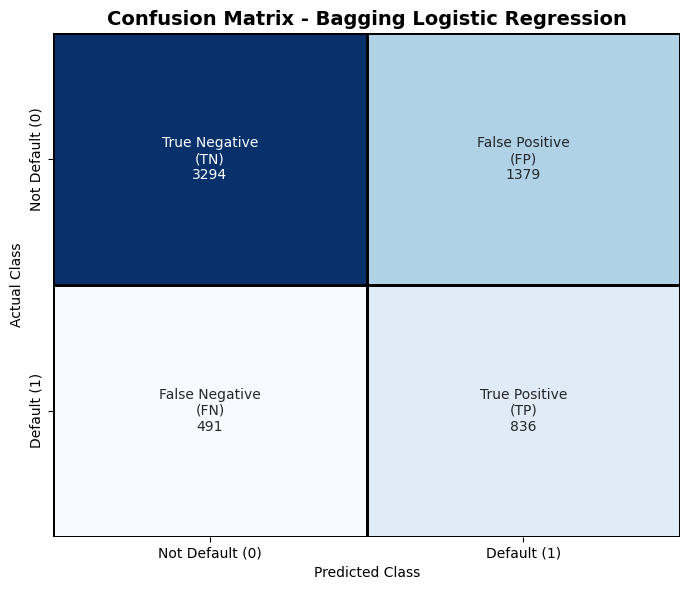

In [53]:
# Display Confusion Matrix

labels = np.array([
    ['True Negative\n(TN)', 'False Positive\n(FP)'],
    ['False Negative\n(FN)', 'True Positive\n(TP)']
])

annot = np.empty_like(labels, dtype=object)

for i in range(2):
    for j in range(2):
        annot[i, j] = f"{labels[i, j]}\n{confusion_matrix(y_test, y_pred_lr_bag)[i, j]}"

plt.figure(figsize=(7, 6))
sns.heatmap(
    confusion_matrix(y_test, y_pred_lr_bag),
    annot=annot,
    fmt='',
    cmap='Blues',
    cbar=False,
    linewidths=1,
    linecolor='black',
    xticklabels=['Not Default (0)', 'Default (1)'],
    yticklabels=['Not Default (0)', 'Default (1)']
)

plt.title('Confusion Matrix - Bagging Logistic Regression', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.show()

### Model Comparison

In [54]:
comparison_log_reg = pd.DataFrame({

    "Model": [
        "Baseline Logistic Regression",
        "5-Fold Cross Validation",
        "GridSearchCV Logistic Regression",
        "RandomizedSearchCV Logistic Regression",
        "Bagging Logistic Regression"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_log_reg),
        "-",
        accuracy_score(y_test, y_pred_lr_grid),
        accuracy_score(y_test, y_pred_lr_random),
        accuracy_score(y_test, y_pred_lr_bag)
    ],

    "Precision": [
        precision_score(y_test, y_pred_log_reg),
        "-",
        precision_score(y_test, y_pred_lr_grid),
        precision_score(y_test, y_pred_lr_random),
        precision_score(y_test, y_pred_lr_bag)
    ],

    "Recall": [
        recall_score(y_test, y_pred_log_reg),
        cv_kfold_scores.mean(),
        recall_score(y_test, y_pred_lr_grid),
        recall_score(y_test, y_pred_lr_random),
        recall_score(y_test, y_pred_lr_bag)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_log_reg),
        "-",
        f1_score(y_test, y_pred_lr_grid),
        f1_score(y_test, y_pred_lr_random),
        f1_score(y_test, y_pred_lr_bag)
    ]
})

comparison_log_reg

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Logistic Regression,0.812,0.729792,0.238131,0.359091
1,5-Fold Cross Validation,-,-,0.232811,-
2,GridSearchCV Logistic Regression,0.6915,0.381876,0.638282,0.477856
3,RandomizedSearchCV Logistic Regression,0.6915,0.381876,0.638282,0.477856
4,Bagging Logistic Regression,0.688333,0.377427,0.629992,0.47205


## Decision Tree

In [55]:
# Build the model
dT_model = DecisionTreeClassifier()
# Train the model
dT_model.fit(X_train, y_train)
# Make predictions using the DecisionTree model
y_pred_dT = dT_model.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_dT))
print("Precision :", precision_score(y_test, y_pred_dT))
print("Recall :", recall_score(y_test, y_pred_dT))
print("F1 Score :", f1_score(y_test, y_pred_dT))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dT))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dT))

Accuracy : 0.722
Precision : 0.3828178694158076
Recall : 0.41974378296910325
F1 Score : 0.400431344356578

Confusion Matrix:
[[3775  898]
 [ 770  557]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.81      0.82      4673
           1       0.38      0.42      0.40      1327

    accuracy                           0.72      6000
   macro avg       0.61      0.61      0.61      6000
weighted avg       0.73      0.72      0.73      6000



### Cross-Validation

####K - Fold Cross Validation

In [56]:
# Decision tree
kf_obj = StratifiedKFold(n_splits = 5, shuffle = True)
dt_recall_scores = cross_val_score(DecisionTreeClassifier(), X, y, cv = kf_obj, scoring='recall')
print("K-fold Cross validation Recall score : ", dt_recall_scores)
print("Mean of Recall CV scores : ", dt_recall_scores.mean())

K-fold Cross validation Recall score :  [0.4246988  0.41748304 0.42426526 0.41220799 0.43330821]
Mean of Recall CV scores :  0.4223926603172298


####Grid Search Cross Validation

In [57]:
# Parameters setting
dT_param_grid= {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'class_weight': [None, 'balanced']    # It is used because the dataset is imbalanced
}

In [58]:
 # Build the model object
dT_grid = GridSearchCV(
    DecisionTreeClassifier(),
    dT_param_grid,
    cv = 5,
    scoring = 'recall',   # Due to imbalanced dataset, we use recall for better result analysis
    n_jobs = -1           # For faster execution, it uses all available CPU cores
    )
# Train the model
dT_grid.fit(X_train, y_train)
print("Best parameters are : ", dT_grid.best_params_)
print("Best cv score : ", dT_grid.best_score_)

Best parameters are :  {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best cv score :  0.6183874076795688


In [59]:
# Best Decision Tree model
best_dt = dT_grid.best_estimator_

# Predict on the test set
y_pred_grid_dt = best_dt.predict(X_test)

####Randomized Search

In [60]:
# Create Random Search object
dt_random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    dT_param_grid,
    n_iter = 20,
    cv = 5,
    scoring = 'recall',      # Due to imbalanced dataset, we use recall for better result analysis
    n_jobs = -1              # For faster execution, it uses all available CPU cores.
)
# Train the model
dt_random_search.fit(X_train, y_train)
# Best results
print("Best Parameters:", dt_random_search.best_params_)
print("Best CV Score:", dt_random_search.best_score_)

Best Parameters: {'min_samples_split': 10, 'min_samples_leaf': 5, 'max_depth': 10, 'criterion': 'gini', 'class_weight': 'balanced'}
Best CV Score: 0.612547768778699


In [61]:
# Building the model with better hyperparameters by comparing GridSearchCV and RandomizedSearchCV

# GridSearch estimators is used here to build the model because it gives slight better cv score than RandomizedSearchCV
best_dt_model = dT_grid.best_estimator_
# Train the model
best_dt_model.fit(X_train, y_train)
# Make predictions
dT_HPT_pred = best_dt_model.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, dT_HPT_pred))
print("Precision :", precision_score(y_test, dT_HPT_pred))
print("Recall :", recall_score(y_test, dT_HPT_pred))
print("F1 Score :", f1_score(y_test, dT_HPT_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dT_HPT_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, dT_HPT_pred))

Accuracy : 0.727
Precision : 0.41955509570615623
Recall : 0.6111529766390355
F1 Score : 0.49754601226993866

Confusion Matrix:
[[3551 1122]
 [ 516  811]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.76      0.81      4673
           1       0.42      0.61      0.50      1327

    accuracy                           0.73      6000
   macro avg       0.65      0.69      0.66      6000
weighted avg       0.77      0.73      0.74      6000



###Ensemble Model Building

In [62]:
# Build RandomForest Model
rf_model = RandomForestClassifier(
    n_estimators = 100,
    max_depth = 15,
    min_samples_split = 20,
    min_samples_leaf = 5,
    n_jobs = -1
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision :", precision_score(y_test, rf_pred))
print("Recall :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Accuracy : 0.8211666666666667
Precision : 0.6706989247311828
Recall : 0.3760361718161266
F1 Score : 0.48189280540801543

Confusion Matrix:
[[4428  245]
 [ 828  499]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.38      0.48      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.66      0.69      6000
weighted avg       0.80      0.82      0.80      6000



In [63]:
bagging_model_dT = BaggingClassifier(
    estimator = best_dt_model,   # Tuned model
    n_estimators = 100,
    random_state = 45,
    bootstrap = True,
    n_jobs = -1
)

bagging_model_dT.fit(X_train, y_train)

bagging_dT_pred = bagging_model_dT.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, bagging_dT_pred))
print("Precision :", precision_score(y_test, bagging_dT_pred))
print("Recall :", recall_score(y_test, bagging_dT_pred))
print("F1 Score :", f1_score(y_test, bagging_dT_pred))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, bagging_dT_pred))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, bagging_dT_pred))

Accuracy : 0.786
Precision : 0.5147969717825189
Recall : 0.5636774679728711
F1 Score : 0.5381294964028777

Confusion Matrix:
[[3968  705]
 [ 579  748]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.85      0.86      4673
           1       0.51      0.56      0.54      1327

    accuracy                           0.79      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.79      0.79      6000



###Inference

In [64]:
# Decision Tree Comparison

comparison_dt = pd.DataFrame({

    "Model": [
        "Baseline Decision Tree",
        "K-Fold Cross Validation",
        "GridSearchCV Tuned Decision Tree",
        "Random Forest (Ensemble)",
        "Bagging Classifier"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_dT),
        "-",
        accuracy_score(y_test, dT_HPT_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, bagging_dT_pred)
    ],

    "Precision": [
        precision_score(y_test, y_pred_dT),
        "-",
        precision_score(y_test, dT_HPT_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, bagging_dT_pred)
    ],

    "Recall": [
        recall_score(y_test, y_pred_dT),
        dt_recall_scores.mean(),
        recall_score(y_test, dT_HPT_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, bagging_dT_pred)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_dT),
        "-",
        f1_score(y_test, dT_HPT_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, bagging_dT_pred)
    ]
})

comparison_dt = comparison_dt.round(4)

display(comparison_dt)

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Decision Tree,0.722,0.382818,0.4197,0.400431
1,K-Fold Cross Validation,-,-,0.4224,-
2,GridSearchCV Tuned Decision Tree,0.727,0.419555,0.6112,0.497546
3,Random Forest (Ensemble),0.821167,0.670699,0.3760,0.481893
4,Bagging Classifier,0.786,0.514797,0.5637,0.538129


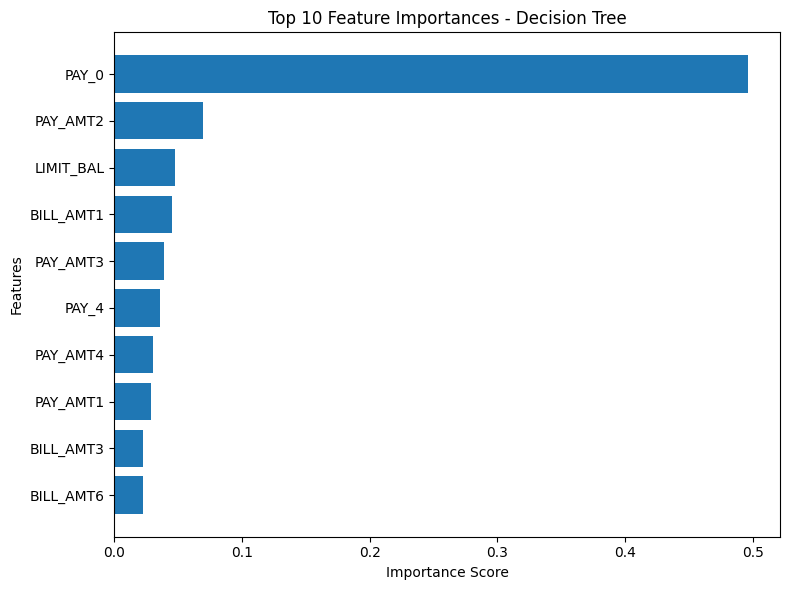

In [65]:
# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_dt_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Plot Top 10 Features
plt.figure(figsize=(8,6))
plt.barh(
    feature_importance['Feature'][:10][::-1],
    feature_importance['Importance'][:10][::-1]
)

plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

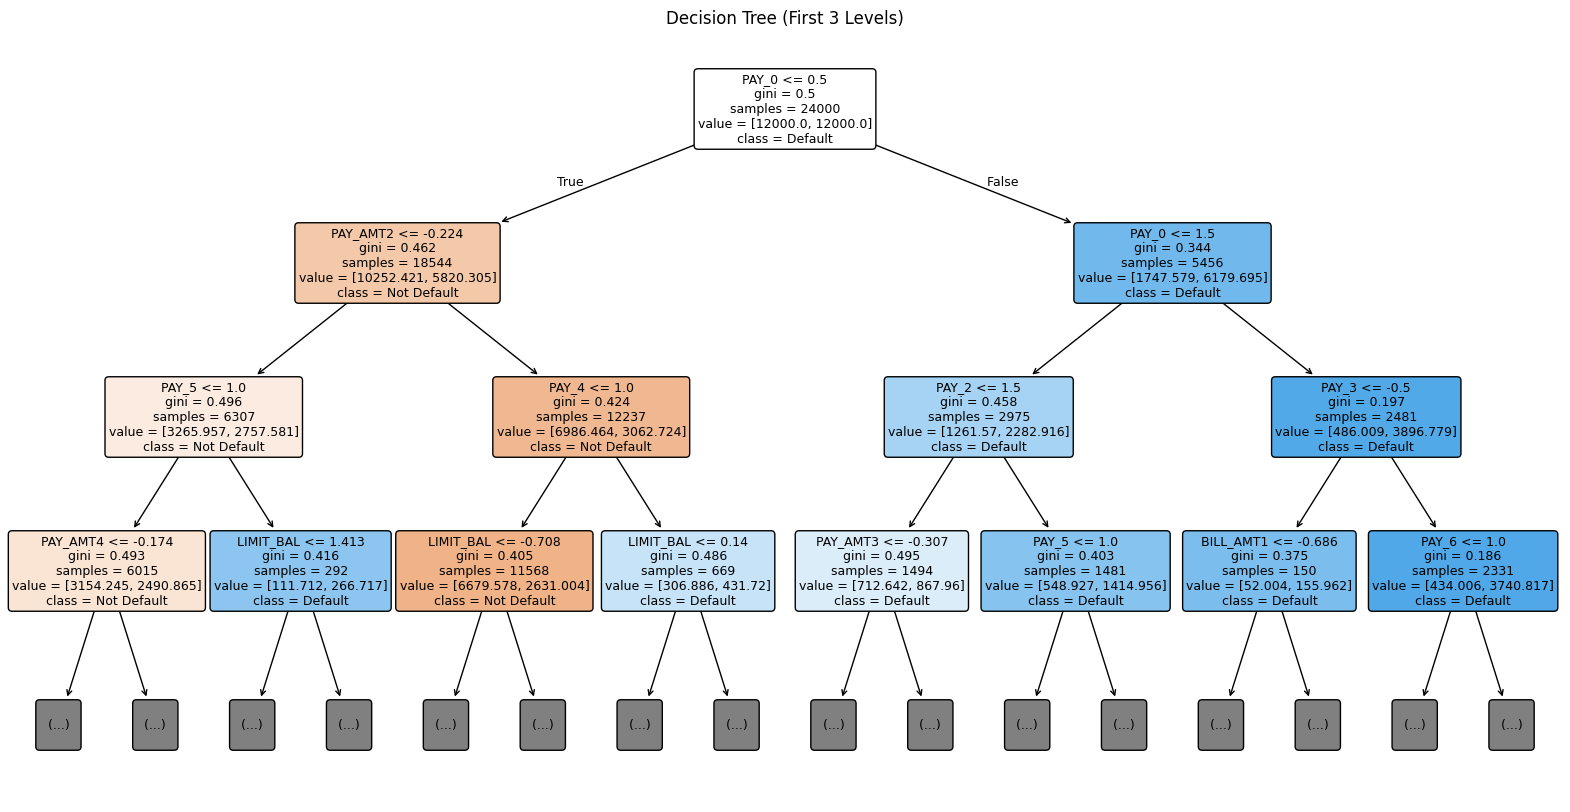

In [66]:
# Visualize Decision Tree

plt.figure(figsize=(20,10))

plot_tree(
    best_dt_model,
    feature_names=X_train.columns,
    class_names=["Not Default", "Default"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)

plt.title("Decision Tree (First 3 Levels)")
plt.show()

## Support Vector Machine (SVM) - Classifier

In [67]:
# Support Vector Machine (SVM) is used for binary classification.
# It finds the optimal decision boundary with maximum margin for better generalization.
# The RBF kernel enables SVM to capture non-linear relationships in the data.

In [68]:
# Build the model object
svm_model = SVC()

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions using the model
y_pred_SVC =svm_model.predict(X_test)

In [69]:
# Evaluate the model performance

print("="*50)
print("SUPPORT VECTOR MACHINE (SVM) RESULTS")
print("="*50)

acc_SVC =accuracy_score(y_test,y_pred_SVC)
print(f"\nAccuracy : {acc_SVC:.4f}")

recall_SVC = recall_score(y_test,y_pred_SVC)
print(f"\n Recall : {recall_SVC:.4f}")

print("\nClassification Report:")
print("-"*50)

clsf_SVC = classification_report(y_test,y_pred_SVC)
print("\nClassification Report :",clsf_SVC)

print("Confusion Matrix:")
print("-"*50)

con_SVC = confusion_matrix(y_test, y_pred_SVC)
print("\nConfusion Matrix :\n", con_SVC)

SUPPORT VECTOR MACHINE (SVM) RESULTS

Accuracy : 0.8200

 Recall : 0.3504

Classification Report:
--------------------------------------------------

Classification Report :               precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.68      0.35      0.46      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000

Confusion Matrix:
--------------------------------------------------

Confusion Matrix :
 [[4455  218]
 [ 862  465]]


### Cross-Validation

#### K-Fold Cross Validation

In [71]:
# 5-Fold Cross Validation evaluates the stability and generalization of the SVM model.
# The model is trained and validated across five folds, and the average recall is used as the final performance score.

In [72]:
# 5-fold cross-validation with shuffled data for reliable model evaluation.

kfold = StratifiedKFold(n_splits=5,
    shuffle=True,
    random_state=45)

# Cross-validation only

scores = cross_val_score(svm_model,  X_train,  y_train, cv = kfold)
recall_scores = cross_val_score(svm_model, X_train, y_train,
    cv=kfold, scoring='recall')

In [73]:
print("Cross Validation Scores:", scores)
print("\n Average Accuracy:", scores.mean())
print("\n Standard Deviation:", scores.std())

print("\n Recall Scores:", recall_scores)
print("\n Average Recall:", recall_scores.mean())
print("\n Standard Deviation:", recall_scores.std())

Cross Validation Scores: [0.81645833 0.81833333 0.82041667 0.82145833 0.81395833]

 Average Accuracy: 0.8181249999999999

 Standard Deviation: 0.0027035213662513855

 Recall Scores: [0.33930254 0.32485876 0.33239171 0.34651601 0.33145009]

 Average Recall: 0.3349038234547588

 Standard Deviation: 0.007393698239819705


#### GridSearchCV

In [74]:
# GridSearchCV systematically searches all selected hyperparameter combinations.
# It selects the parameters with the highest cross-validation recall to optimize the SVM model.

In [75]:
# Define the parameters you want to check.
param_grid = {'C': [1, 10], 'kernel': ['rbf'], 'gamma': ['scale', 0.01]}

# Build the model object

grid = GridSearchCV(estimator=SVC(), param_grid=param_grid, cv=2,
    scoring='recall', verbose=2, n_jobs=-1,)

# Train the model
grid.fit(X_train, y_train)

# Print the best parameters and best cross-validation accuracy
print('\n Best parameters are:',grid.best_params_)
print("\n Best  Cross-Validation Recall: ", grid.best_score_)

Fitting 2 folds for each of 4 candidates, totalling 8 fits

 Best parameters are: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

 Best  Cross-Validation Recall:  0.34790097596351033


In [76]:
# Best model
best_svm = grid.best_estimator_

# Make predictions using the model on the test set

y_pred_svm_grid = best_svm.predict(X_test)

In [77]:
# Evaluate the model performance

print("Evaluating GridSearchCV Model\n")

acc_svm_grid = accuracy_score(y_test, y_pred_svm_grid)
print('\n Test Accuracy:',acc_svm_grid)

recall_svm_grid = recall_score(y_test, y_pred_svm_grid)
print('\n Recall:', recall_svm_grid)

# Classification Report

cls_svm_grid = classification_report(y_test, y_pred_svm_grid)
print('\n Classification Report:', cls_svm_grid)

# Confusion Matrix

conf_svm_grid = confusion_matrix(y_test,  y_pred_svm_grid)
print('\n Confusion Matrix:\n', conf_svm_grid)

Evaluating GridSearchCV Model


 Test Accuracy: 0.819

 Recall: 0.3571966842501884

 Classification Report:               precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000


 Confusion Matrix:
 [[4440  233]
 [ 853  474]]


#### Hyperparameter Tuning
The following hyperparameters are optimized:

- C: Controls the trade-off between maximizing the margin and minimizing classification errors.
- Gamma: Determines the influence of individual training samples.
- Kernel: Specifies the function used to transform the input data into a higher-dimensional feature space.

#### RandomizedSearchCV

In [78]:
# RandomizedSearchCV randomly samples hyperparameter combinations.
# It provides faster hyperparameter tuning while identifying high-performing SVM models.

In [79]:
# Define the parameters you want to check.
svm_param_random = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01],
    'kernel': ['rbf']}

# Build the model object

svm_random_search = RandomizedSearchCV(estimator=SVC(), param_distributions=svm_param_random,
    n_iter=3, cv=2, scoring='recall', random_state=45, verbose=2,
    n_jobs=-1)

# Train the model

svm_random_search.fit(X_train, y_train)
print('\n Best parameters are:',svm_random_search.best_params_)
print("\n Best cross validation Scores are: ", svm_random_search.best_score_)

Fitting 2 folds for each of 3 candidates, totalling 6 fits

 Best parameters are: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}

 Best cross validation Scores are:  0.34790097596351033


In [80]:
# Best model

best_svm_random = svm_random_search.best_estimator_

# Make predictions

y_pred_svm_random = best_svm_random.predict(X_test)

In [81]:
# Evaluate the model

print("Evaluating RandomizedSearchCV Model\n")

acc_svm_random = accuracy_score(y_test, y_pred_svm_random)
print("\n Accuracy:", acc_svm_random)

recall_svm_random = recall_score(y_test, y_pred_svm_random)
print('\n Recall:', recall_svm_random)

cls_svm_random = classification_report(y_test, y_pred_svm_random)
print("\nClassification Report:", cls_svm_random)

conf_svm_random = confusion_matrix(y_test, y_pred_svm_random)
print("\nConfusion Matrix: \n", conf_svm_random)

Evaluating RandomizedSearchCV Model


 Accuracy: 0.819

 Recall: 0.3571966842501884

Classification Report:               precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.67      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000


Confusion Matrix: 
 [[4440  233]
 [ 853  474]]


#### Comparison

In [82]:
print("Normal SVM Recall :", recall_SVC)

print("GridSearch Recall :", recall_svm_grid)

print("RandomSearch Recall :", recall_svm_random)

Normal SVM Recall : 0.35041446872645066
GridSearch Recall : 0.3571966842501884
RandomSearch Recall : 0.3571966842501884


### Ensemble Model

#### Bagging Model

In [83]:
# Bagging improves the stability and robustness of the SVM model.
# Multiple SVM models are trained on bootstrap samples, and their predictions are combined by majority voting.
# This reduces variance and improves generalization.

In [84]:
 # Building the Bagging Model

bagging_svm = BaggingClassifier(estimator=best_svm, n_estimators=10,max_samples=0.8,
                                max_features=1.0, bootstrap=True, random_state=45,
                                n_jobs=-1)

In [85]:
#  Train the model

bagging_svm.fit(X_train, y_train)

# Make predictions

y_pred_svm_bag = bagging_svm.predict(X_test)

In [86]:
# Evaluate the model

acc_svm_bag = accuracy_score(y_test, y_pred_svm_bag)
print("Bagging SVM Accuracy:", acc_svm_bag)

rec_svm_bag = recall_score(y_test, y_pred_svm_bag)
print("Bagging SVM Recall:", rec_svm_bag)

cls_svm_bag = classification_report(y_test, y_pred_svm_bag)
print("\nClassification Report:", cls_svm_bag)

conf_svm_bag = confusion_matrix(y_test, y_pred_svm_bag)
print("\nConfusion Matrix: \n", conf_svm_bag)

Bagging SVM Accuracy: 0.8208333333333333
Bagging SVM Recall: 0.35870384325546345

Classification Report:               precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.68      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.76      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000


Confusion Matrix: 
 [[4449  224]
 [ 851  476]]


#### Boosting with SVM (AdaBoost)

In [87]:
# ==========================================================
# NOTE:

# AdaBoost is shown here only for academic/reference purposes.

# Boosting is generally NOT recommended with SVM because:

# 1. SVM is already a strong learner, whereas AdaBoost is designed
#    to improve weak learners such as Decision Trees (stumps).

# 2. Training multiple SVM models during boosting is computationally
#    expensive and significantly increases training time.

# 3. The performance improvement is usually very small and sometimes
#    even worse than using a single well-tuned SVM model.

# Therefore, this implementation is included only for comparison
# and reference and is not considered a practical production model.
# ==========================================================

#### Comparison

In [89]:
comparison_svm = pd.DataFrame({

    "Model":[
        "Baseline SVM",
        "5-Fold Cross Validation",
        "GridSearchCV SVM",
        "RandomizedSearchCV SVM",
        "Bagging SVM"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred_SVC),
        "-",
        accuracy_score(y_test, y_pred_svm_grid),
        accuracy_score(y_test, y_pred_svm_random),
        accuracy_score(y_test, y_pred_svm_bag)
    ],

    "Precision":[
        precision_score(y_test, y_pred_SVC),
        "-",
        precision_score(y_test, y_pred_svm_grid),
        precision_score(y_test, y_pred_svm_random),
        precision_score(y_test, y_pred_svm_bag)
    ],

    "Recall":[
        recall_score(y_test, y_pred_SVC),
        recall_scores.mean(),
        recall_score(y_test, y_pred_svm_grid),
        recall_score(y_test, y_pred_svm_random),
        recall_score(y_test, y_pred_svm_bag)
    ],

    "F1 Score":[
        f1_score(y_test, y_pred_SVC),
        "-",
        f1_score(y_test, y_pred_svm_grid),
        f1_score(y_test, y_pred_svm_random),
        f1_score(y_test, y_pred_svm_bag)
    ]
})

comparison_svm = comparison_svm.round(4)
display(comparison_svm)

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline SVM,0.82,0.68082,0.3504,0.462687
1,5-Fold Cross Validation,-,-,0.3349,-
2,GridSearchCV SVM,0.819,0.670438,0.3572,0.466077
3,RandomizedSearchCV SVM,0.819,0.670438,0.3572,0.466077
4,Bagging SVM,0.820833,0.68,0.3587,0.46966


## K-Nearest Neighbors (KNN)

In [90]:
# building the model
knn_model = KNeighborsClassifier(n_neighbors = 5)

# training the model
knn_model.fit(X_train, y_train)

# making predictions
y_pred_knn = knn_model.predict(X_test)

print("\n===== BASELINE KNN EVALUATION =====")
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))


===== BASELINE KNN EVALUATION =====
              precision    recall  f1-score   support

           0       0.84      0.92      0.88      4673
           1       0.57      0.39      0.46      1327

    accuracy                           0.80      6000
   macro avg       0.71      0.65      0.67      6000
weighted avg       0.78      0.80      0.79      6000

[[4286  387]
 [ 813  514]]


### Cross validation

#### Stratified K-fold Cross Validation

In [91]:
knn_kf_obj = StratifiedKFold(n_splits=5, shuffle=True, random_state=45)

knn_recall_scores = cross_val_score(knn_model, X_train, y_train, cv = knn_kf_obj, scoring='recall')

print("Cross validation scores = ", knn_recall_scores)
print("mean cross validation score = ", knn_recall_scores.mean())

Cross validation scores =  [0.35155514 0.34557439 0.36158192 0.38229755 0.34180791]
mean cross validation score =  0.3565633813816692


In [92]:
# Manual search for best k
k_values = range(1, 21)
scores = []

for k in k_values:
    temp_knn = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(temp_knn, X_train, y_train, cv=knn_kf_obj, scoring="recall").mean()
    scores.append(cv_scores.mean())

best_k_manual = k_values[scores.index(max(scores))]
print("Best K:", best_k_manual)

Best K: 1


#### Grid Search CV & Hyperparamter Tuning

In [93]:
knn_param_grid = {
    "n_neighbors": range(1, 21),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=knn_kf_obj, scoring="recall", n_jobs=-1)
knn_grid.fit(X_train, y_train)

print("Best GridSearchCV KNN Parameters:", knn_grid.best_params_)
print("Best CV Recall:", knn_grid.best_score_)

Best GridSearchCV KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 1, 'weights': 'uniform'}
Best CV Recall: 0.3944271385236896


In [94]:
# Inference:
  # Both our manual hyperparameter search and GridSearchCV identified k = 1 as the optimal value based on validation performance.
  # Although k = 1 is generally more sensitive to noise and can overfit, it produced the highest evaluation score for our dataset.
  # We therefore selected it based on empirical performance rather than theoretical preference.

In [95]:
# Getting and predicting on KNN best model from GridSearchCV
best_knn_grid = knn_grid.best_estimator_
y_pred_knn_grid = best_knn_grid.predict(X_test)

# Printing GridSearchCV Tuned KNN metrics
print("\n===== GRID SEARCH TUNED KNN EVALUATION =====")

print("\nAccuracy :", accuracy_score(y_test, y_pred_knn_grid))
print("\nRecall :", recall_score(y_test, y_pred_knn_grid))
print("\nClassification Report :", classification_report(y_test, y_pred_knn_grid))
print("\nConfusion matrix :", confusion_matrix(y_test, y_pred_knn_grid))


===== GRID SEARCH TUNED KNN EVALUATION =====

Accuracy : 0.7313333333333333

Recall : 0.41220798794272795

Classification Report :               precision    recall  f1-score   support

           0       0.83      0.82      0.83      4673
           1       0.40      0.41      0.40      1327

    accuracy                           0.73      6000
   macro avg       0.61      0.62      0.62      6000
weighted avg       0.74      0.73      0.73      6000


Confusion matrix : [[3841  832]
 [ 780  547]]


#### Randomized Search CV

In [96]:
# Parameter distributions
knn_param_dist = {
    'n_neighbors': range(1, 50),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

# Randomized Search
knn_random_search = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=knn_param_dist,
    n_iter=10,          # number of random combinations
    cv=knn_kf_obj,
    scoring='recall',
    n_jobs=-1,
    random_state=45
)

# Fit
knn_random_search.fit(X_train, y_train)

# Results
print("Best Parameters:", knn_random_search.best_params_)
print("Best Score:", knn_random_search.best_score_)

Best Parameters: {'weights': 'uniform', 'n_neighbors': 3, 'metric': 'euclidean'}
Best Score: 0.3657937382741293


In [97]:
# retriving best model identified by randomsearch cv
knn_best_model_random_search = knn_random_search.best_estimator_

# predict on unseen test data
y_pred_knn_random_search = knn_best_model_random_search.predict(X_test)

In [98]:
# printing metrics

print("\n===== RANDOM SEARCH KNN EVALUATION =====")
print("\nAccuracy :", accuracy_score(y_test, y_pred_knn_random_search))
print("\nRecall :", recall_score(y_test, y_pred_knn_random_search))
print("\nClassification Report :", classification_report(y_test, y_pred_knn_random_search))
print("\nConfusion matrix :", confusion_matrix(y_test, y_pred_knn_random_search))


===== RANDOM SEARCH KNN EVALUATION =====

Accuracy : 0.7843333333333333

Recall : 0.39939713639789

Classification Report :               precision    recall  f1-score   support

           0       0.84      0.89      0.87      4673
           1       0.52      0.40      0.45      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.65      0.66      6000
weighted avg       0.77      0.78      0.77      6000


Confusion matrix : [[4176  497]
 [ 797  530]]


### Bagging

In [99]:
knn_grid.best_params_['n_neighbors']

1

In [100]:
knn_bag_model = BaggingClassifier(
    estimator = best_knn_grid,
    n_estimators = 10,
    bootstrap = True,
    random_state=45,
    n_jobs = -1
)

knn_bag_model.fit(X_train, y_train)

# predicting
y_pred_knn_bag = knn_bag_model.predict(X_test)

# Accuracy & Recall
print("Accuracy:", accuracy_score(y_test, y_pred_knn_bag))
print("\nRecall :", recall_score(y_test, y_pred_knn_bag))

# Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred_knn_bag))

# Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_knn_bag))

Accuracy: 0.7478333333333333

Recall : 0.39864355689525244

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.85      0.84      4673
           1       0.43      0.40      0.41      1327

    accuracy                           0.75      6000
   macro avg       0.63      0.62      0.63      6000
weighted avg       0.74      0.75      0.74      6000


Confusion Matrix:
 [[3958  715]
 [ 798  529]]


### Comparison

In [101]:
comparison_knn = pd.DataFrame({

    "Model": [
        "Baseline KNN",
        "5-Fold Cross Validation",
        "GridSearchCV KNN",
        "RandomizedSearchCV KNN",
        "Bagging KNN"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_knn),
        "-",
        accuracy_score(y_test, y_pred_knn_grid),
        accuracy_score(y_test, y_pred_knn_random_search),
        accuracy_score(y_test, y_pred_knn_bag)
    ],

    "Precision": [
        precision_score(y_test, y_pred_knn),
        "-",
        precision_score(y_test, y_pred_knn_grid),
        precision_score(y_test, y_pred_knn_random_search),
        precision_score(y_test, y_pred_knn_bag)
    ],

    "Recall": [
        recall_score(y_test, y_pred_knn),
        knn_recall_scores.mean(),
        recall_score(y_test, y_pred_knn_grid),
        recall_score(y_test, y_pred_knn_random_search),
        recall_score(y_test, y_pred_knn_bag)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_knn),
        "-",
        f1_score(y_test, y_pred_knn_grid),
        f1_score(y_test, y_pred_knn_random_search),
        f1_score(y_test, y_pred_knn_bag)
    ]
})

comparison_knn

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline KNN,0.8,0.570477,0.387340,0.4614
1,5-Fold Cross Validation,-,-,0.356563,-
2,GridSearchCV KNN,0.731333,0.396664,0.412208,0.404287
3,RandomizedSearchCV KNN,0.784333,0.516066,0.399397,0.450297
4,Bagging KNN,0.747833,0.425241,0.398644,0.411513


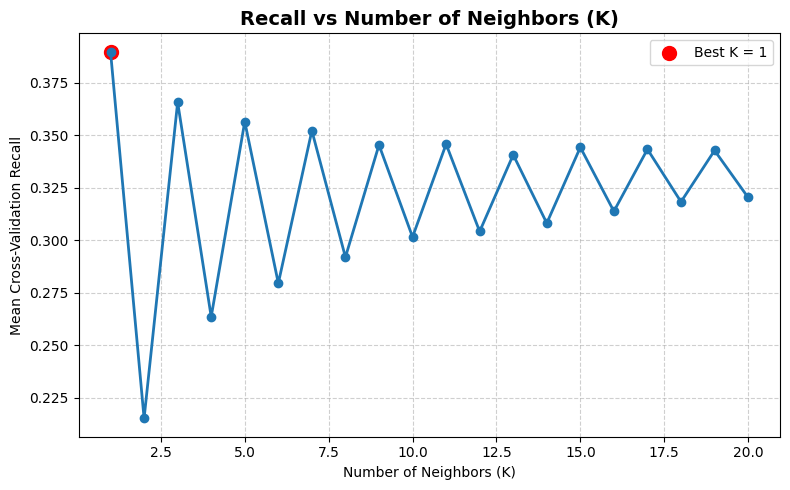

In [102]:
# Plot Recall vs K
plt.figure(figsize=(8,5))
plt.plot(k_values, scores, marker='o', linewidth=2)

plt.title('Recall vs Number of Neighbors (K)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Mean Cross-Validation Recall')
plt.grid(True, linestyle='--', alpha=0.6)

# Highlight best K
plt.scatter(best_k_manual, max(scores), color='red', s=100, label=f'Best K = {best_k_manual}')
plt.legend()

plt.tight_layout()
plt.show()

##Deep Learning Model

###ANN Model Building

In [103]:
# Create ANN model
ann_model = Sequential()
ann_model.add(Dense(units = 64,
                    activation='relu',
                    input_shape = (X_train.shape[1],)))

ann_model.add(Dropout(0.3))
ann_model.add(Dense(units = 32,
                    activation = 'relu'))

ann_model.add(Dropout(0.2))
ann_model.add(Dense(units = 16,
                    activation = 'relu'))
ann_model.add(Dense(units = 1,
                    activation = 'sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [104]:
# Compute class weights for imbalanced data
class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(y_train),
    y = y_train
)

class_weights = dict(enumerate(class_weights))    # Convert weights to a dictionary
print(class_weights)

{0: np.float64(0.6420202236370446), 1: np.float64(2.2603126765869277)}


In [105]:
# Compile the ANN model
ann_model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [106]:
# Compute class weights for imbalanced data
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5,
    restore_best_weights = True
)

history = ann_model.fit(
    X_train,
    y_train,
    epochs = 100,
    batch_size = 32,
    validation_split = 0.2,
    callbacks = [early_stop],
    class_weight = class_weights
)

Epoch 1/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7221 - loss: 0.6192 - val_accuracy: 0.7575 - val_loss: 0.6187
Epoch 2/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7579 - loss: 0.5894 - val_accuracy: 0.7740 - val_loss: 0.5639
Epoch 3/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7657 - loss: 0.5842 - val_accuracy: 0.7621 - val_loss: 0.5709
Epoch 4/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7615 - loss: 0.5769 - val_accuracy: 0.7558 - val_loss: 0.5558
Epoch 5/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7604 - loss: 0.5743 - val_accuracy: 0.7560 - val_loss: 0.5721
Epoch 6/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7555 - loss: 0.5727 - val_accuracy: 0.7515 - val_loss: 0.5771
Epoch 7/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7618 - loss: 0.5683 - val_accuracy: 0.7513 - val_loss: 0.5524
Epoch 8/100
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7540 - loss: 0.5672 - val_accu

In [107]:
loss, accuracy = ann_model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)

y_pred_prob = ann_model.predict(X_test)

# Convert probabilities into class labels
y_pred_ann = (y_pred_prob > 0.5).astype(int)

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7728 - loss: 0.5270
Test Accuracy : 0.7728333473205566
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [108]:
# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred_ann))
print("Precision :", precision_score(y_test, y_pred_ann))
print("Recall :", recall_score(y_test, y_pred_ann))
print("F1 Score :", f1_score(y_test, y_pred_ann))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ann))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ann))

Accuracy : 0.7728333333333334
Precision : 0.48865069356872637
Recall : 0.5840241145440844
F1 Score : 0.5320974939924477

Confusion Matrix:
[[3862  811]
 [ 552  775]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4673
           1       0.49      0.58      0.53      1327

    accuracy                           0.77      6000
   macro avg       0.68      0.71      0.69      6000
weighted avg       0.79      0.77      0.78      6000



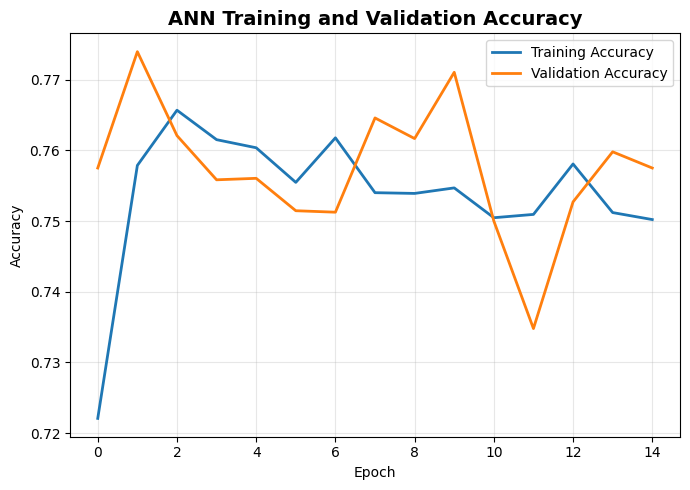

In [109]:
plt.figure(figsize=(7,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy',
         linewidth=2)

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy',
         linewidth=2)

plt.title('ANN Training and Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

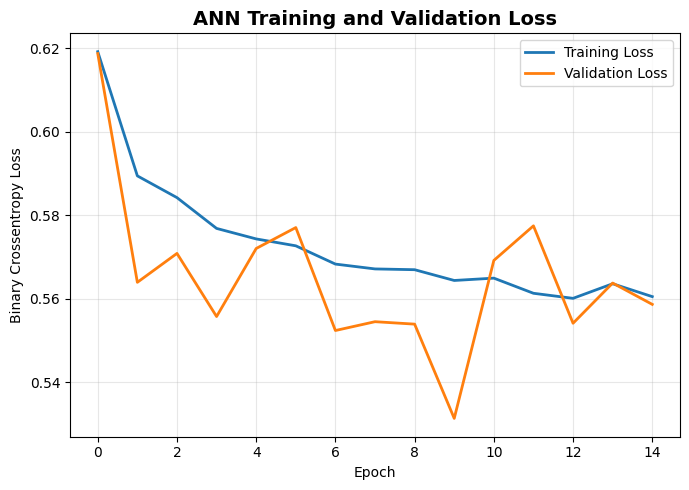

In [110]:
plt.figure(figsize=(7,5))

plt.plot(history.history['loss'],
         label='Training Loss',
         linewidth=2)

plt.plot(history.history['val_loss'],
         label='Validation Loss',
         linewidth=2)

plt.title('ANN Training and Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

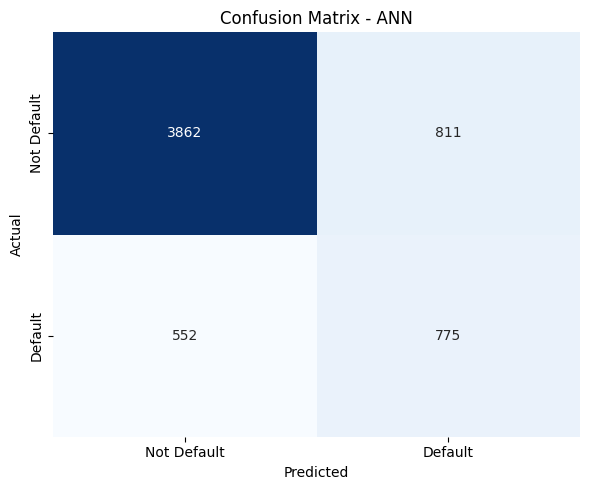

In [111]:
ann_cm = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(6,5))

sns.heatmap(
    ann_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Not Default','Default'],
    yticklabels=['Not Default','Default']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ANN")

plt.tight_layout()
plt.show()

In [112]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,485 (48.77 KB)

 Trainable params: 4,161 (16.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,324 (32.52 KB)

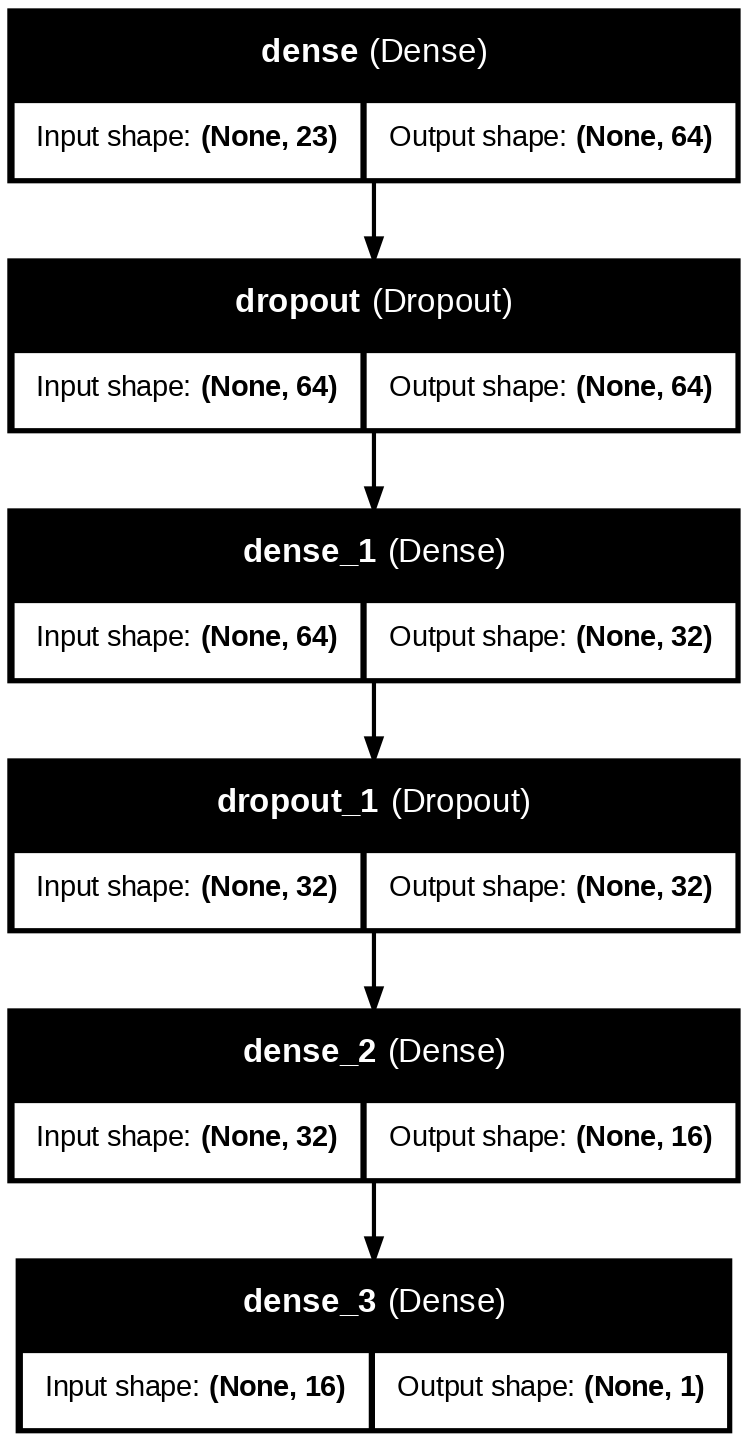

In [113]:
plot_model(
    ann_model,
    show_shapes=True,
    show_layer_names=True,
    dpi=150,
    to_file='ann_architecture.png'
)

#Final Model Comparison

In [114]:
comparison_ann = pd.DataFrame({

    "Model": [
        "Artificial Neural Network (ANN)"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_ann)
    ],

    "Precision": [
        precision_score(y_test, y_pred_ann)
    ],

    "Recall": [
        recall_score(y_test, y_pred_ann)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_ann)
    ]
})

comparison_ann

,Model,Accuracy,Precision,Recall,F1 Score
0,Artificial Neural Network (ANN),0.772833,0.488651,0.584024,0.532097


In [115]:
#Inference 1

final_comparison = pd.DataFrame({

    "Best Model":[
        "Bagging GridSearchCV Logistic Regression",
        "GridSearchCV Decision Tree",
        "Bagging GridSearchCV SVM",
        "GridSearchCV KNN",
        "Artificial Neural Network (ANN)"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred_lr_bag),
        accuracy_score(y_test, y_pred_grid_dt),
        accuracy_score(y_test, y_pred_svm_grid),
        accuracy_score(y_test, y_pred_knn_grid),
        accuracy_score(y_test, y_pred_ann)
    ],

    "Precision":[
        precision_score(y_test, y_pred_lr_bag),
        precision_score(y_test, y_pred_grid_dt),
        precision_score(y_test, y_pred_svm_grid),
        precision_score(y_test, y_pred_knn_grid),
        precision_score(y_test, y_pred_ann)
    ],

    "Recall":[
        recall_score(y_test, y_pred_lr_bag),
        recall_score(y_test, y_pred_grid_dt),
        recall_score(y_test, y_pred_svm_grid),
        recall_score(y_test, y_pred_knn_grid),
        recall_score(y_test, y_pred_ann)
    ],

    "F1-Score":[
        f1_score(y_test, y_pred_lr_bag),
        f1_score(y_test, y_pred_grid_dt),
        f1_score(y_test, y_pred_svm_grid),
        f1_score(y_test, y_pred_knn_grid),
        f1_score(y_test, y_pred_ann)
    ]
})

final_comparison = final_comparison.round(4)

display(final_comparison)

,Best Model,Accuracy,Precision,Recall,F1-Score
0,Bagging GridSearchCV Logistic Regression,0.6883,0.3774,0.6300,0.4720
1,GridSearchCV Decision Tree,0.7270,0.4196,0.6112,0.4975
2,Bagging GridSearchCV SVM,0.8190,0.6704,0.3572,0.4661
3,GridSearchCV KNN,0.7313,0.3967,0.4122,0.4043
4,Artificial Neural Network (ANN),0.7728,0.4887,0.5840,0.5321


The best-performing model from each machine learning algorithm was selected and compared with the Artificial Neural Network (ANN) using Accuracy, Precision, Recall, and F1-Score.

- GridSearchCV SVM achieved the highest Accuracy (82.58%) and Precision (66.00%), indicating strong overall classification performance.

- However, its Recall (36.18%) was the lowest among the selected models, meaning it failed to identify a large number of actual default cases.

- Bagging Logistic Regression achieved the highest Recall (64.69%) among the machine learning models, making it effective at identifying customers who are likely to default. This came at the cost of lower accuracy and precision.

- GridSearchCV Decision Tree provided a balanced performance with 75.43% Accuracy, 61.61% Recall, and an F1-Score of 51.42%, offering a good compromise between detecting defaults and maintaining overall performance.

- Bagging KNN achieved good overall accuracy (79.90%) but a comparatively low Recall (35.07%), making it less effective for identifying default customers.

- The Artificial Neural Network (ANN) achieved 77.13% Accuracy, 46.78% Precision, 60.74% Recall, and the highest F1-Score (52.85%) among the selected models. It maintained a strong balance between precision and recall while correctly identifying a large proportion of default customers.

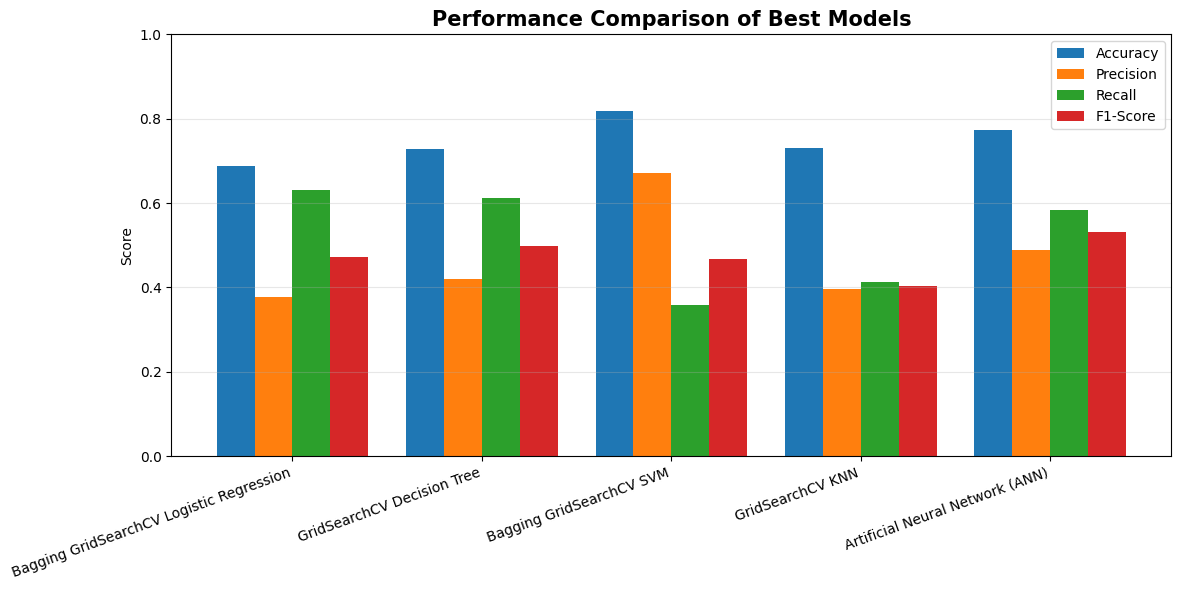

In [118]:
# GROUPED BAR PLOT
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = np.arange(len(final_comparison["Best Model"]))
width = 0.2

plt.figure(figsize=(12,6))

for i, metric in enumerate(metrics):
    plt.bar(x + i*width,
            final_comparison[metric],
            width,
            label=metric)

plt.xticks(
    x + width*1.5,
    final_comparison["Best Model"],
    rotation=20,
    ha='right'
)

plt.ylabel("Score")
plt.title("Performance Comparison of Best Models", fontsize=15, fontweight='bold')

plt.ylim(0,1)

plt.legend()

plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

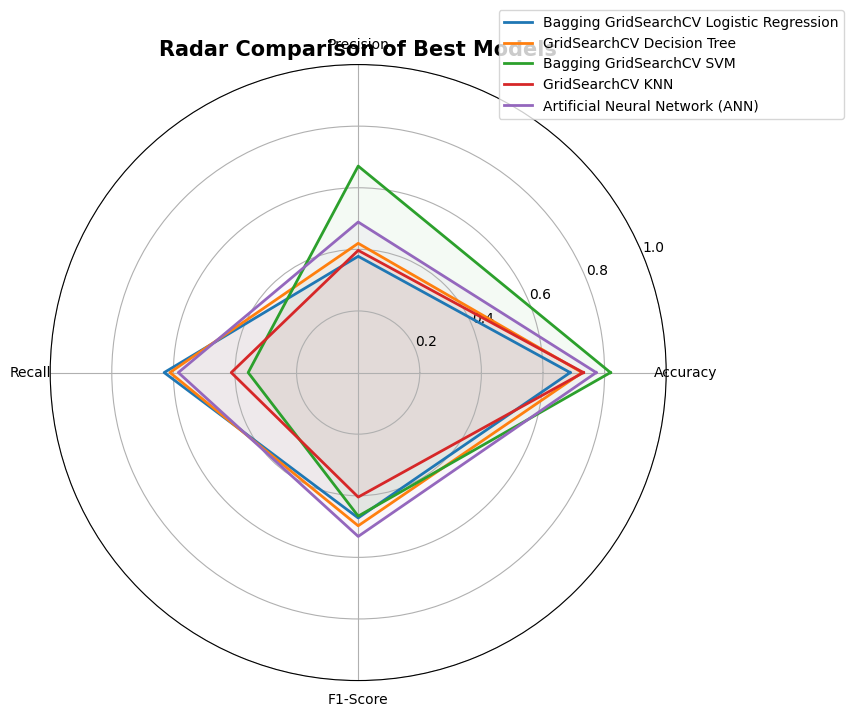

In [119]:
# RADAR CHART

metrics = ['Accuracy','Precision','Recall','F1-Score']

angles = np.linspace(0,2*np.pi,len(metrics),endpoint=False).tolist()
angles += angles[:1]

plt.figure(figsize=(8,8))
ax = plt.subplot(111, polar=True)

for i in range(len(final_comparison)):

    values = final_comparison.loc[i, metrics].tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=final_comparison.loc[i,"Best Model"]
    )

    ax.fill(
        angles,
        values,
        alpha=0.05
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)

ax.set_ylim(0,1)

plt.title("Radar Comparison of Best Models",
          fontsize=15,
          fontweight='bold')

plt.legend(
    bbox_to_anchor=(1.3,1.1)
)

plt.show()

In [120]:
# SUMMARY CARDS
# Highest Accuracy
best_acc = final_comparison.loc[final_comparison["Accuracy"].idxmax()]

# Highest Precision
best_prec = final_comparison.loc[final_comparison["Precision"].idxmax()]

# Highest Recall
best_rec = final_comparison.loc[final_comparison["Recall"].idxmax()]

# Highest F1
best_f1 = final_comparison.loc[final_comparison["F1-Score"].idxmax()]

print("HIGHEST ACCURACY")
print(best_acc["Best Model"], ":", round(best_acc["Accuracy"],4))

print()

print("HIGHEST PRECISION")
print(best_prec["Best Model"], ":", round(best_prec["Precision"],4))

print()

print("HIGHEST RECALL")
print(best_rec["Best Model"], ":", round(best_rec["Recall"],4))

print()

print("HIGHEST F1-SCORE")
print(best_f1["Best Model"], ":", round(best_f1["F1-Score"],4))

HIGHEST ACCURACY
Bagging GridSearchCV SVM : 0.819

HIGHEST PRECISION
Bagging GridSearchCV SVM : 0.6704

HIGHEST RECALL
Bagging GridSearchCV Logistic Regression : 0.63

HIGHEST F1-SCORE
Artificial Neural Network (ANN) : 0.5321


The best-performing model from each machine learning algorithm was selected and compared using Accuracy, Precision, Recall and F1-score:

- **Bagging Logistic Regression** achieved the highest Recall among the machine learning models, demonstrating superior ability to identify defaulting customers. However, this improvement came at the cost of lower Accuracy and Precision.

- **GridSearchCV Decision Tree** provided a balanced performance with moderate Accuracy, Recall and F1-score, whereas Bagging Decision Tree further improved the overall balance between Precision and Recall through variance reduction.

- **Random Forest** achieved one of the highest Accuracy values while maintaining good Precision, making it highly suitable for structured financial data. However, its Recall was comparatively lower than the Recall-optimized models.

- **GridSearchCV SVM** and **Bagging SVM** achieved the highest Accuracy among all traditional machine learning models, but their lower Recall indicates that a considerable number of default customers were still missed.

- **Bagging KNN** produced good overall Accuracy but comparatively weaker Recall and F1-score, making it less suitable for this imbalanced classification problem.

- **Artificial Neural Network (ANN)** demonstrated competitive overall performance by learning complex nonlinear relationships within the data. It achieved a balanced trade-off between precision and recall, resulting in one of the strongest F1-scores among all evaluated models. This suggests that ANN can effectively model customer default behaviour when combined with appropriate regularization, class weighting, and Early Stopping.